# **Install the dataset library**

In [1]:
%pip install -q ucimlrepo

# **IMPORTS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

# LOAD THE **DATASET**

In [3]:
# Fetch the UCI Heart Disease dataset
dataset = fetch_ucirepo(id=45)

X = dataset.data.features.copy()
y_raw = dataset.data.targets.iloc[:, 0].copy()

print("Feature shape:", X.shape)
print("\nFeature columns:")
print(X.columns.tolist())

print("\nMissing values per feature:")
print(X.isna().sum())

print("\nOriginal target distribution:")
print(y_raw.value_counts(dropna=False).sort_index())

print("\nFirst five rows:")
display(X.head())

Feature shape: (303, 13)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Missing values per feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


# **CREATE THE BINARY TARGET**

In [4]:

# Convert the original target to numeric values
target_numeric = pd.to_numeric(y_raw, errors="coerce")

# Identify records that have a valid target label
valid_target = target_numeric.notna()

# Keep only records with known target labels
X = X.loc[valid_target].copy()
target_numeric = target_numeric.loc[valid_target]

# Convert the original five-category target to a binary target
y = (target_numeric > 0).astype(int)

print("Feature shape after target validation:", X.shape)
print("\nBinary target distribution:")
print(y.value_counts().sort_index())

print("\nTotal records:", len(X))
print("Missing target labels:", target_numeric.isna().sum())

Feature shape after target validation: (303, 13)

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64

Total records: 303
Missing target labels: 0


# **TRAIN, TEST AND SPLIT**

In [5]:

from sklearn.model_selection import train_test_split

# Generate row positions for the split
row_positions = np.arange(len(X))

train_idx, test_idx = train_test_split(
    row_positions,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Select the corresponding feature rows and target labels
X_train_raw = X.iloc[train_idx].copy()
X_test_raw = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training records:", len(X_train_raw))
print("Testing records:", len(X_test_raw))

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training records: 242
Testing records: 61

Training target distribution:
num
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
num
0    33
1    28
Name: count, dtype: int64


### **PREPROCESSING PIPELINE**

In [6]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Continuous numerical measurements
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Categorical or discrete coded features
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Process continuous features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Process categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate pipeline to each column group
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Learn preprocessing parameters from training data only
X_train = preprocessor.fit_transform(X_train_raw)

# Apply the learned transformations to test data
X_test = preprocessor.transform(X_test_raw)

print("Original number of features:", X_train_raw.shape[1])
print("Processed training shape:", X_train.shape)
print("Processed testing shape:", X_test.shape)
print("Missing values remaining in raw training data:", X_train_raw.isna().sum().sum())


Original number of features: 13
Processed training shape: (242, 28)
Processed testing shape: (61, 28)
Missing values remaining in raw training data: 2


# **TRAIN THE LOGISTIC REGRESSION BASELINE**

In [7]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create the baseline classifier
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train using the processed training features and labels
lr_model.fit(X_train, y_train)

# Predict the class for each test record
y_pred_lr = lr_model.predict(X_test)

# Predict the probability of the positive class
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")
print("Number of test predictions:", len(y_pred_lr))
print("First 10 predictions:", y_pred_lr[:10])
print("First 10 positive-class probabilities:", y_prob_lr[:10])

Logistic Regression trained successfully.
Number of test predictions: 61
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 positive-class probabilities: [0.20929567 0.60145782 0.02148916 0.03334708 0.3118407  0.01557081
 0.11681799 0.34861394 0.72209751 0.34742282]


# **EVALUATE THE MODEL**

In [8]:

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, zero_division=0)
recall = recall_score(y_test, y_pred_lr, zero_division=0)
f1 = f1_score(y_test, y_pred_lr, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION — TEST RESULTS")
print("-" * 40)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No recorded disease", "Recorded disease"],
    zero_division=0
))

LOGISTIC REGRESSION — TEST RESULTS
----------------------------------------
Accuracy : 0.885
Precision: 0.839
Recall   : 0.929
F1-score : 0.881
ROC-AUC  : 0.966

Confusion Matrix:
[[28  5]
 [ 2 26]]

Classification Report:
                     precision    recall  f1-score   support

No recorded disease       0.93      0.85      0.89        33
   Recorded disease       0.84      0.93      0.88        28

           accuracy                           0.89        61
          macro avg       0.89      0.89      0.89        61
       weighted avg       0.89      0.89      0.89        61



# **SAVE THE BASELINE RESULTS**

In [9]:

baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

baseline_df = pd.DataFrame([baseline_results])

display(baseline_df.round(3))


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.885,0.839,0.929,0.881,0.966


# BUILD THE PATIENT SIMILARITY **GRAPH**
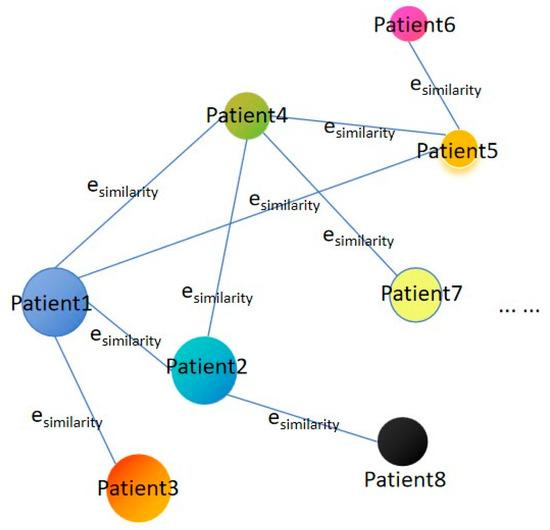

Node: one patient.



Node features: that patient's 28 processed features.



Edge: a connection between two similar patients.



Node label: the patient's binary target, used only when that record is included in supervised training.

# **INSTALL PYTORCH GEOMETRIC**

In [10]:
%pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00


VERIFICATION

In [11]:

import torch
import torch_geometric

print("PyTorch version:", torch.__version__)
print("PyTorch Geometric version:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cpu
PyTorch Geometric version: 2.8.0.post1
CUDA available: False


# BUILD THE TRAINING **GRAPH**

In [12]:

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import issparse
import numpy as np
import torch

# Convert processed features to dense arrays for this small dataset
X_train_dense = (
    X_train.toarray() if issparse(X_train) else np.asarray(X_train)
).astype(np.float32)

X_test_dense = (
    X_test.toarray() if issparse(X_test) else np.asarray(X_test)
).astype(np.float32)

# Number of nearest neighbors per patient
K = 5

# Find nearest training patients
train_neighbors_model = NearestNeighbors(
    n_neighbors=K + 1,
    metric="euclidean"
)
train_neighbors_model.fit(X_train_dense)

distances, neighbor_indices = train_neighbors_model.kneighbors(
    X_train_dense
)

# Construct undirected edges between training patients
edge_set = set()

for patient_idx, neighbors in enumerate(neighbor_indices):
    added = 0

    for neighbor_idx in neighbors:
        neighbor_idx = int(neighbor_idx)

        # Do not connect a patient to itself
        if neighbor_idx == patient_idx:
            continue

        # Store edges in both directions
        edge_set.add((patient_idx, neighbor_idx))
        edge_set.add((neighbor_idx, patient_idx))

        added += 1
        if added == K:
            break

# PyTorch Geometric expects edge_index with shape [2, number_of_edges]
edge_index_train = torch.tensor(
    list(edge_set),
    dtype=torch.long
).t().contiguous()

# Store training features and labels as tensors
x_train_tensor = torch.tensor(
    X_train_dense,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.long
)

print("Training nodes:", x_train_tensor.shape[0])
print("Features per node:", x_train_tensor.shape[1])
print("Directed edges:", edge_index_train.shape[1])
print("Edge index shape:", tuple(edge_index_train.shape))
print("Training labels:", y_train_tensor.shape)

Training nodes: 242
Features per node: 28
Directed edges: 1794
Edge index shape: (2, 1794)
Training labels: torch.Size([242])


# **CONNECT TEST PATIENTS TO TRAINING PATIENTS**

In [13]:

# Find each test patient's five nearest training patients
test_neighbors_model = NearestNeighbors(
    n_neighbors=K,
    metric="euclidean"
)
test_neighbors_model.fit(X_train_dense)

test_distances, test_neighbor_indices = (
    test_neighbors_model.kneighbors(X_test_dense)
)

n_train = len(X_train_dense)

# Test nodes use indices after the training nodes
test_edge_set = set()

for test_idx, train_neighbors in enumerate(test_neighbor_indices):
    global_test_idx = n_train + test_idx

    for train_idx in train_neighbors:
        # Directed edge: training patient -> test patient
        test_edge_set.add((int(train_idx), global_test_idx))

edge_index_test = torch.tensor(
    list(test_edge_set),
    dtype=torch.long
).t().contiguous()

print("Test nodes:", len(X_test_dense))
print("Training-to-test edges:", edge_index_test.shape[1])
print("Combined graph nodes:", n_train + len(X_test_dense))
print("Test labels used to build edges: No")

Test nodes: 61
Training-to-test edges: 305
Combined graph nodes: 303
Test labels used to build edges: No


# **DEFINE TEH MODEL**

In [14]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

# Make the experiment more reproducible
torch.manual_seed(42)
np.random.seed(42)

class HeartDiseaseGraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # First layer: aggregate information from neighbouring patients
        self.conv1 = SAGEConv(input_dim, hidden_dim)

        # Second layer: learn more complex patterns
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        # Convert the learned representation into class scores
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)

        self.dropout = 0.3

    def forward(self, x, edge_index):
        # First round of neighbour aggregation
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second round of neighbour aggregation
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Predict the probability scores indirectly through logits
        return self.classifier(x)


model = HeartDiseaseGraphSAGE(
    input_dim=x_train_tensor.shape[1],
    hidden_dim=32,
    num_classes=2
)

print(model)

HeartDiseaseGraphSAGE(
  (conv1): SAGEConv(28, 32, aggr=mean)
  (conv2): SAGEConv(32, 32, aggr=mean)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)


# **TRAIN ON THE TRAINING GRAPH ONLY**

In [15]:

from torch_geometric.utils import coalesce

# Remove any duplicate edges and standardize edge representation
edge_index_train = coalesce(
    edge_index_train,
    num_nodes=len(X_train_dense)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=0.005
)

criterion = torch.nn.CrossEntropyLoss()

epochs = 200

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # The model sees training features and training edges only
    logits = model(x_train_tensor, edge_index_train)

    # Every training patient has a known binary label
    loss = criterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1:3d}/{epochs} | Loss: {loss.item():.4f}")

print("Training complete.")

Epoch  25/200 | Loss: 0.3385
Epoch  50/200 | Loss: 0.2435
Epoch  75/200 | Loss: 0.1695
Epoch 100/200 | Loss: 0.1074
Epoch 125/200 | Loss: 0.0866
Epoch 150/200 | Loss: 0.0729
Epoch 175/200 | Loss: 0.0760
Epoch 200/200 | Loss: 0.0756
Training complete.


# **PREDICT THE HELD OUT TEST PATIENTS**

In [16]:

# Give the test patients node indices 242 through 302
x_test_tensor = torch.tensor(
    X_test_dense,
    dtype=torch.float32
)

x_combined = torch.cat(
    [x_train_tensor, x_test_tensor],
    dim=0
)

# Preserve training edges and add training-to-test edges
edge_index_combined = torch.cat(
    [edge_index_train, edge_index_test],
    dim=1
)

model.eval()

with torch.no_grad():
    combined_logits = model(
        x_combined,
        edge_index_combined
    )

    # Test nodes occupy the final 61 rows
    test_logits = combined_logits[len(X_train_dense):]

    y_pred_gnn = test_logits.argmax(dim=1).cpu().numpy()

    y_prob_gnn = torch.softmax(
        test_logits,
        dim=1
    )[:, 1].cpu().numpy()

print("Test predictions:", len(y_pred_gnn))
print("Test probabilities:", len(y_prob_gnn))
print("Training labels used in fitting:", len(y_train_tensor))

Test predictions: 61
Test probabilities: 61
Training labels used in fitting: 242


# **EVALUATE THE GNN**

In [17]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

gnn_results = {
    "Model": "GraphSAGE",
    "Accuracy": accuracy_score(y_test, y_pred_gnn),
    "Precision": precision_score(y_test, y_pred_gnn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_gnn, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_gnn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gnn)
}

gnn_df = pd.DataFrame([gnn_results])

display(gnn_df.round(3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_gnn))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_gnn,
    target_names=["No recorded disease", "Recorded disease"],
    zero_division=0
))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,GraphSAGE,0.852,0.771,0.964,0.857,0.96


Confusion matrix:
[[25  8]
 [ 1 27]]

Classification report:
                     precision    recall  f1-score   support

No recorded disease       0.96      0.76      0.85        33
   Recorded disease       0.77      0.96      0.86        28

           accuracy                           0.85        61
          macro avg       0.87      0.86      0.85        61
       weighted avg       0.87      0.85      0.85        61



# **CREATE A FINAL COMPARISON TABLE**

In [18]:

comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.885,
        "Precision": 0.839,
        "Recall": 0.929,
        "F1-score": 0.881,
        "ROC-AUC": 0.966
    },
    gnn_results
])

display(
    comparison_df
    .set_index("Model")
    .round(3)
)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.885,0.839,0.929,0.881,0.966
GraphSAGE,0.852,0.771,0.964,0.857,0.960


# **VALIDATION SET FOR TUNING**

In [19]:

from sklearn.model_selection import train_test_split
from scipy.sparse import issparse
import numpy as np
import torch

# Split the existing training indices, not the full dataset.
# Stratification preserves the proportion of each class.
inner_train_idx, val_idx = train_test_split(
    np.arange(len(X_train_raw)),
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

X_inner_raw = X_train_raw.iloc[inner_train_idx].copy()
X_val_raw = X_train_raw.iloc[val_idx].copy()

y_inner = y_train.iloc[inner_train_idx].copy()
y_val = y_train.iloc[val_idx].copy()

# Fit preprocessing only on the new, smaller training split.
# Validation data must not influence imputation, scaling, or encoding.
X_inner = preprocessor.fit_transform(X_inner_raw)
X_val = preprocessor.transform(X_val_raw)

X_inner_dense = (
    X_inner.toarray() if issparse(X_inner) else np.asarray(X_inner)
).astype(np.float32)

X_val_dense = (
    X_val.toarray() if issparse(X_val) else np.asarray(X_val)
).astype(np.float32)

y_inner_tensor = torch.tensor(
    y_inner.to_numpy(), dtype=torch.long
)

y_val_array = y_val.to_numpy()

print("New training patients:", len(X_inner_dense))
print("Validation patients:", len(X_val_dense))
print("Final test patients (still untouched):", len(X_test_raw))
print("Training class counts:")
print(y_inner.value_counts().sort_index())
print("Validation class counts:")
print(y_val.value_counts().sort_index())
print("Processed feature count:", X_inner_dense.shape[1])

New training patients: 193
Validation patients: 49
Final test patients (still untouched): 61
Training class counts:
num
0    104
1     89
Name: count, dtype: int64
Validation class counts:
num
0    27
1    22
Name: count, dtype: int64
Processed feature count: 28


# **GRAPH CONSTRUCTION AND HYPERPARAMETER TUNING**

In [20]:

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import issparse
import numpy as np
import torch

# Convert the training and validation features to PyTorch tensors
x_inner_tensor = torch.tensor(
    X_inner_dense, dtype=torch.float32
)

x_val_tensor = torch.tensor(
    X_val_dense, dtype=torch.float32
)

# Number of neighbours to connect to each patient
K = 5

# Build the graph using training patients only
inner_neighbors_model = NearestNeighbors(
    n_neighbors=K + 1,
    metric="euclidean"
)
inner_neighbors_model.fit(X_inner_dense)

_, inner_neighbor_indices = (
    inner_neighbors_model.kneighbors(X_inner_dense)
)

# Create bidirectional edges between training patients
inner_edge_set = set()

for patient_idx, neighbors in enumerate(inner_neighbor_indices):
    added = 0

    for neighbor_idx in neighbors:
        neighbor_idx = int(neighbor_idx)

        # Do not connect a patient to itself
        if neighbor_idx == patient_idx:
            continue

        inner_edge_set.add((patient_idx, neighbor_idx))
        inner_edge_set.add((neighbor_idx, patient_idx))

        added += 1
        if added == K:
            break

edge_index_inner = torch.tensor(
    list(inner_edge_set), dtype=torch.long
).t().contiguous()

# Connect each validation patient to its K nearest training patients.
# Validation patients cannot become neighbours of training patients.
val_neighbors_model = NearestNeighbors(
    n_neighbors=K,
    metric="euclidean"
)
val_neighbors_model.fit(X_inner_dense)

_, val_neighbor_indices = (
    val_neighbors_model.kneighbors(X_val_dense)
)

n_inner = len(X_inner_dense)
val_edge_set = set()

for val_idx, neighbors in enumerate(val_neighbor_indices):
    global_val_idx = n_inner + val_idx

    for train_idx in neighbors:
        # Directed edge: training patient -> validation patient
        val_edge_set.add((int(train_idx), global_val_idx))

edge_index_val = torch.tensor(
    list(val_edge_set), dtype=torch.long
).t().contiguous()

print("Training nodes:", x_inner_tensor.shape[0])
print("Validation nodes:", x_val_tensor.shape[0])
print("Features per node:", x_inner_tensor.shape[1])
print("Training edges:", edge_index_inner.shape[1])
print("Training-to-validation edges:", edge_index_val.shape[1])
print("Validation labels used to build edges: No")

Training nodes: 193
Validation nodes: 49
Features per node: 28
Training edges: 1422
Training-to-validation edges: 245
Validation labels used to build edges: No


# **RUN THE TUNING EXPERIMENT**

In [21]:

import copy
import itertools
import pandas as pd
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# A configurable version of our earlier GraphSAGE model
class TunableHeartDiseaseGraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()

        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, 2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(
            x, p=self.dropout, training=self.training
        )

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        return self.classifier(x)


# Combine training and validation nodes for validation inference.
# Training nodes retain their original incoming neighbourhoods.
x_combined_tuning = torch.cat(
    [x_inner_tensor, x_val_tensor], dim=0
)

edge_index_combined_tuning = torch.cat(
    [edge_index_inner, edge_index_val], dim=1
)

# Hyperparameter combinations: 3 x 2 x 2 = 12 experiments
configurations = list(itertools.product(
    [16, 32, 64],       # hidden dimensions
    [0.2, 0.4],         # dropout
    [0.005, 0.01]       # learning rate
))

weight_decay = 0.005
max_epochs = 200
patience = 25

tuning_results = []
best_overall_f1 = -1
best_config = None
best_model_state = None

for config_number, (hidden_dim, dropout, lr) in enumerate(
    configurations, start=1
):
    torch.manual_seed(42)

    model_tune = TunableHeartDiseaseGraphSAGE(
        input_dim=x_inner_tensor.shape[1],
        hidden_dim=hidden_dim,
        dropout=dropout
    )

    optimizer_tune = torch.optim.Adam(
        model_tune.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion_tune = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_epoch_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        # Train exclusively on the inner training graph
        model_tune.train()
        optimizer_tune.zero_grad()

        train_logits = model_tune(
            x_inner_tensor, edge_index_inner
        )
        train_loss = criterion_tune(
            train_logits, y_inner_tensor
        )

        train_loss.backward()
        optimizer_tune.step()

        # Evaluate on validation nodes only
        model_tune.eval()

        with torch.no_grad():
            combined_logits = model_tune(
                x_combined_tuning,
                edge_index_combined_tuning
            )

            val_logits = combined_logits[
                len(X_inner_dense):
            ]

            val_loss = criterion_tune(
                val_logits,
                torch.tensor(y_val_array, dtype=torch.long)
            ).item()

        # Keep the checkpoint with the lowest validation loss
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_epoch_state = copy.deepcopy(
                model_tune.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # Evaluate this configuration at its best validation-loss epoch
    model_tune.load_state_dict(best_epoch_state)
    model_tune.eval()

    with torch.no_grad():
        combined_logits = model_tune(
            x_combined_tuning,
            edge_index_combined_tuning
        )
        val_logits = combined_logits[len(X_inner_dense):]
        val_probabilities = torch.softmax(
            val_logits, dim=1
        )[:, 1].cpu().numpy()

    val_predictions = (val_probabilities >= 0.5).astype(int)

    val_accuracy = accuracy_score(
        y_val_array, val_predictions
    )
    val_precision = precision_score(
        y_val_array, val_predictions, zero_division=0
    )
    val_recall = recall_score(
        y_val_array, val_predictions, zero_division=0
    )
    val_f1 = f1_score(
        y_val_array, val_predictions, zero_division=0
    )
    val_auc = roc_auc_score(
        y_val_array, val_probabilities
    )

    result = {
        "Hidden dim": hidden_dim,
        "Dropout": dropout,
        "Learning rate": lr,
        "Weight decay": weight_decay,
        "Best epoch": best_epoch,
        "Val loss": best_val_loss,
        "Accuracy": val_accuracy,
        "Precision": val_precision,
        "Recall": val_recall,
        "F1-score": val_f1,
        "ROC-AUC": val_auc
    }

    tuning_results.append(result)

    print(
        f"Config {config_number:02d}/{len(configurations)} | "
        f"Hidden={hidden_dim}, Dropout={dropout}, LR={lr} | "
        f"Val F1={val_f1:.3f}, Val AUC={val_auc:.3f}"
    )

    # Choose using validation F1; use ROC-AUC to break ties
    if (
        val_f1 > best_overall_f1
        or (
            val_f1 == best_overall_f1
            and (
                best_config is None
                or val_auc > best_config["ROC-AUC"]
            )
        )
    ):
        best_overall_f1 = val_f1
        best_config = result.copy()
        best_model_state = copy.deepcopy(
            model_tune.state_dict()
        )

# Display configurations ranked by validation performance
tuning_df = pd.DataFrame(tuning_results).sort_values(
    ["F1-score", "ROC-AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(tuning_df.round(3))

print("Best configuration selected using validation data:")
print(best_config)

Config 01/12 | Hidden=16, Dropout=0.2, LR=0.005 | Val F1=0.810, Val AUC=0.958
Config 02/12 | Hidden=16, Dropout=0.2, LR=0.01 | Val F1=0.818, Val AUC=0.955
Config 03/12 | Hidden=16, Dropout=0.4, LR=0.005 | Val F1=0.864, Val AUC=0.958
Config 04/12 | Hidden=16, Dropout=0.4, LR=0.01 | Val F1=0.837, Val AUC=0.960
Config 05/12 | Hidden=32, Dropout=0.2, LR=0.005 | Val F1=0.844, Val AUC=0.946
Config 06/12 | Hidden=32, Dropout=0.2, LR=0.01 | Val F1=0.889, Val AUC=0.951
Config 07/12 | Hidden=32, Dropout=0.4, LR=0.005 | Val F1=0.864, Val AUC=0.948
Config 08/12 | Hidden=32, Dropout=0.4, LR=0.01 | Val F1=0.870, Val AUC=0.953
Config 09/12 | Hidden=64, Dropout=0.2, LR=0.005 | Val F1=0.837, Val AUC=0.939
Config 10/12 | Hidden=64, Dropout=0.2, LR=0.01 | Val F1=0.837, Val AUC=0.939
Config 11/12 | Hidden=64, Dropout=0.4, LR=0.005 | Val F1=0.837, Val AUC=0.936
Config 12/12 | Hidden=64, Dropout=0.4, LR=0.01 | Val F1=0.837, Val AUC=0.934


,Hidden dim,Dropout,Learning rate,Weight decay,Best epoch,Val loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,32,0.2,0.010,0.005,34,0.289,0.898,0.870,0.909,0.889,0.951
1,32,0.4,0.010,0.005,60,0.296,0.878,0.833,0.909,0.870,0.953
2,16,0.4,0.005,0.005,88,0.284,0.878,0.864,0.864,0.864,0.958
3,32,0.4,0.005,0.005,54,0.302,0.878,0.864,0.864,0.864,0.948
4,32,0.2,0.005,0.005,51,0.295,0.857,0.826,0.864,0.844,0.946
5,16,0.4,0.010,0.005,52,0.291,0.857,0.857,0.818,0.837,0.960
6,64,0.2,0.005,0.005,27,0.314,0.857,0.857,0.818,0.837,0.939
7,64,0.2,0.010,0.005,16,0.312,0.857,0.857,0.818,0.837,0.939
8,64,0.4,0.005,0.005,28,0.322,0.857,0.857,0.818,0.837,0.936
9,64,0.4,0.010,0.005,27,0.317,0.857,0.857,0.818,0.837,0.934


Best configuration selected using validation data:
{'Hidden dim': 32, 'Dropout': 0.2, 'Learning rate': 0.01, 'Weight decay': 0.005, 'Best epoch': 34, 'Val loss': 0.28865012526512146, 'Accuracy': 0.8979591836734694, 'Precision': 0.8695652173913043, 'Recall': 0.9090909090909091, 'F1-score': 0.8888888888888888, 'ROC-AUC': np.float64(0.9511784511784511)}


# **TUNUNG THE GRAPH TO GET BETTER RESULTS**

In [22]:

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import copy
import pandas as pd
import torch

K_values = [3, 5, 7, 10]
graph_tuning_results = []

best_graph_f1 = -1
best_graph_config = None
best_graph_state = None
best_graph_edges = None

for K_try in K_values:
    # 1. Build a training-only graph for this K
    nn_train = NearestNeighbors(
        n_neighbors=K_try + 1,
        metric="euclidean"
    )
    nn_train.fit(X_inner_dense)
    _, train_neighbours = nn_train.kneighbors(X_inner_dense)

    train_edges = set()

    for patient_idx, neighbours in enumerate(train_neighbours):
        added = 0
        for neighbour_idx in neighbours:
            neighbour_idx = int(neighbour_idx)
            if neighbour_idx == patient_idx:
                continue

            train_edges.add((patient_idx, neighbour_idx))
            train_edges.add((neighbour_idx, patient_idx))
            added += 1

            if added == K_try:
                break

    edge_train_try = torch.tensor(
        list(train_edges), dtype=torch.long
    ).t().contiguous()

    # 2. Connect validation nodes only to training nodes
    nn_val = NearestNeighbors(
        n_neighbors=K_try,
        metric="euclidean"
    )
    nn_val.fit(X_inner_dense)
    _, val_neighbours = nn_val.kneighbors(X_val_dense)

    val_edges = set()
    n_train_nodes = len(X_inner_dense)

    for val_idx, neighbours in enumerate(val_neighbours):
        val_node = n_train_nodes + val_idx
        for train_idx in neighbours:
            val_edges.add((int(train_idx), val_node))

    edge_val_try = torch.tensor(
        list(val_edges), dtype=torch.long
    ).t().contiguous()

    combined_edges_try = torch.cat(
        [edge_train_try, edge_val_try], dim=1
    )

    # 3. Train using the previously selected neural-network settings
    torch.manual_seed(42)

    model_try = TunableHeartDiseaseGraphSAGE(
        input_dim=x_inner_tensor.shape[1],
        hidden_dim=32,
        dropout=0.2
    )

    optimizer_try = torch.optim.Adam(
        model_try.parameters(),
        lr=0.01,
        weight_decay=0.005
    )

    criterion_try = torch.nn.CrossEntropyLoss()
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(200):
        model_try.train()
        optimizer_try.zero_grad()

        train_logits = model_try(
            x_inner_tensor, edge_train_try
        )
        train_loss = criterion_try(
            train_logits, y_inner_tensor
        )

        train_loss.backward()
        optimizer_try.step()

        model_try.eval()
        with torch.no_grad():
            combined_logits = model_try(
                x_combined_tuning, combined_edges_try
            )
            val_logits = combined_logits[n_train_nodes:]

            val_loss = criterion_try(
                val_logits,
                torch.tensor(y_val_array, dtype=torch.long)
            ).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_try.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 25:
            break

    # 4. Evaluate this graph at its best validation-loss checkpoint
    model_try.load_state_dict(best_state)
    model_try.eval()

    with torch.no_grad():
        logits = model_try(
            x_combined_tuning, combined_edges_try
        )[n_train_nodes:]

        probabilities = torch.softmax(
            logits, dim=1
        )[:, 1].cpu().numpy()

    predictions = (probabilities >= 0.5).astype(int)

    result = {
        "K": K_try,
        "Best epoch": best_epoch,
        "Val loss": best_val_loss,
        "Accuracy": accuracy_score(y_val_array, predictions),
        "Precision": precision_score(
            y_val_array, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val_array, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_val_array, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val_array, probabilities)
    }

    graph_tuning_results.append(result)

    if (
        result["F1-score"] > best_graph_f1
        or (
            result["F1-score"] == best_graph_f1
            and (
                best_graph_config is None
                or result["ROC-AUC"] > best_graph_config["ROC-AUC"]
            )
        )
    ):
        best_graph_f1 = result["F1-score"]
        best_graph_config = result.copy()
        best_graph_state = copy.deepcopy(model_try.state_dict())
        best_graph_edges = edge_train_try.clone()

graph_tuning_df = pd.DataFrame(
    graph_tuning_results
).sort_values(
    ["F1-score", "ROC-AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(graph_tuning_df.round(3))
print("Best graph configuration:", best_graph_config)

,K,Best epoch,Val loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,7,31,0.274,0.918,0.950,0.864,0.905,0.958
1,5,34,0.289,0.898,0.870,0.909,0.889,0.951
2,10,30,0.298,0.898,0.905,0.864,0.884,0.944
3,3,30,0.291,0.857,0.895,0.773,0.829,0.944


Best graph configuration: {'K': 7, 'Best epoch': 31, 'Val loss': 0.2736680507659912, 'Accuracy': 0.9183673469387755, 'Precision': 0.95, 'Recall': 0.8636363636363636, 'F1-score': 0.9047619047619048, 'ROC-AUC': np.float64(0.9579124579124578)}


# **RETRAIN THE SELECTED GraphSAGE MODEL**

In [23]:

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import issparse
import numpy as np
import torch
import copy

# 1. Refit preprocessing using all 242 original training patients
X_train_final = preprocessor.fit_transform(X_train_raw)
X_test_final = preprocessor.transform(X_test_raw)

X_train_final_dense = (
    X_train_final.toarray()
    if issparse(X_train_final)
    else np.asarray(X_train_final)
).astype(np.float32)

X_test_final_dense = (
    X_test_final.toarray()
    if issparse(X_test_final)
    else np.asarray(X_test_final)
).astype(np.float32)

x_train_final = torch.tensor(
    X_train_final_dense, dtype=torch.float32
)
x_test_final = torch.tensor(
    X_test_final_dense, dtype=torch.float32
)
y_train_final = torch.tensor(
    y_train.to_numpy(), dtype=torch.long
)

# 2. Build a bidirectional training graph with K=7
K_final = 7

nn_train_final = NearestNeighbors(
    n_neighbors=K_final + 1,
    metric="euclidean"
)
nn_train_final.fit(X_train_final_dense)

_, train_neighbours_final = nn_train_final.kneighbors(
    X_train_final_dense
)

train_edge_set_final = set()

for patient_idx, neighbours in enumerate(train_neighbours_final):
    added = 0
    for neighbour_idx in neighbours:
        neighbour_idx = int(neighbour_idx)
        if neighbour_idx == patient_idx:
            continue

        train_edge_set_final.add((patient_idx, neighbour_idx))
        train_edge_set_final.add((neighbour_idx, patient_idx))
        added += 1

        if added == K_final:
            break

edge_index_train_final = torch.tensor(
    list(train_edge_set_final), dtype=torch.long
).t().contiguous()

# 3. Connect test patients to their seven nearest training patients
nn_test_final = NearestNeighbors(
    n_neighbors=K_final,
    metric="euclidean"
)
nn_test_final.fit(X_train_final_dense)

_, test_neighbours_final = nn_test_final.kneighbors(
    X_test_final_dense
)

n_train_final = len(X_train_final_dense)
test_edge_set_final = set()

for test_idx, neighbours in enumerate(test_neighbours_final):
    test_node = n_train_final + test_idx
    for train_idx in neighbours:
        test_edge_set_final.add((int(train_idx), test_node))

edge_index_test_final = torch.tensor(
    list(test_edge_set_final), dtype=torch.long
).t().contiguous()

print("Training nodes:", len(X_train_final_dense))
print("Test nodes:", len(X_test_final_dense))
print("Features per patient:", X_train_final_dense.shape[1])
print("Training edges:", edge_index_train_final.shape[1])
print("Training-to-test edges:", edge_index_test_final.shape[1])

Training nodes: 242
Test nodes: 61
Features per patient: 28
Training edges: 2454
Training-to-test edges: 427


# **TRAIN FOR THE SELECTED NUMBER OF EPOCHS**

In [24]:

torch.manual_seed(42)
np.random.seed(42)

final_model = TunableHeartDiseaseGraphSAGE(
    input_dim=x_train_final.shape[1],
    hidden_dim=32,
    dropout=0.2
)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=0.01,
    weight_decay=0.005
)

final_criterion = torch.nn.CrossEntropyLoss()

for epoch in range(31):
    final_model.train()
    final_optimizer.zero_grad()

    logits = final_model(
        x_train_final, edge_index_train_final
    )

    loss = final_criterion(logits, y_train_final)
    loss.backward()
    final_optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:02d}/31 | "
            f"Training loss: {loss.item():.4f}"
        )

print("Final GraphSAGE training complete.")

Epoch 01/31 | Training loss: 0.7015
Epoch 10/31 | Training loss: 0.3765
Epoch 20/31 | Training loss: 0.3380
Epoch 30/31 | Training loss: 0.3173
Final GraphSAGE training complete.


# **EVALUATE ON THE UNTOUCHED TEST SET**

In [25]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

x_combined_final = torch.cat(
    [x_train_final, x_test_final], dim=0
)

edge_index_combined_final = torch.cat(
    [edge_index_train_final, edge_index_test_final],
    dim=1
)

final_model.eval()

with torch.no_grad():
    final_logits = final_model(
        x_combined_final,
        edge_index_combined_final
    )[n_train_final:]

    final_probabilities = torch.softmax(
        final_logits, dim=1
    )[:, 1].cpu().numpy()

    final_predictions = final_logits.argmax(
        dim=1
    ).cpu().numpy()

final_results = {
    "Model": "Tuned GraphSAGE (K=7)",
    "Accuracy": accuracy_score(y_test, final_predictions),
    "Precision": precision_score(
        y_test, final_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, final_predictions, zero_division=0
    ),
    "F1-score": f1_score(
        y_test, final_predictions, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test, final_probabilities)
}

print("Final test metrics:")
display(pd.DataFrame([final_results]).round(3))

print("Confusion matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=["No recorded disease", "Recorded disease"],
    zero_division=0
))

Final test metrics:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned GraphSAGE (K=7),0.885,0.839,0.929,0.881,0.97


Confusion matrix:
[[28  5]
 [ 2 26]]

Classification report:
                     precision    recall  f1-score   support

No recorded disease       0.93      0.85      0.89        33
   Recorded disease       0.84      0.93      0.88        28

           accuracy                           0.89        61
          macro avg       0.89      0.89      0.89        61
       weighted avg       0.89      0.89      0.89        61



# **LOAD THE NEW MERGED DATASET**

In [26]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

# Find the uploaded CSV file
csv_files = [name for name in uploaded.keys()
             if name.lower().endswith(".csv")]

if not csv_files:
    raise ValueError("Please upload a CSV file.")

df_multi = pd.read_csv(csv_files[0])

print("Dataset loaded successfully!")
print("Shape:", df_multi.shape)
display(df_multi.head())

Saving heart_disease_whole.csv to heart_disease_whole.csv
Dataset loaded successfully!
Shape: (2283, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63,1,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,uci_multi_cleveland
1,67,1,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,uci_multi_cleveland
2,67,1,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,uci_multi_cleveland
3,37,1,3,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,uci_multi_cleveland
4,41,0,2,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,uci_multi_cleveland


# **DATASET QUALITY CHECK**

In [27]:
# 1. Dataset dimensions
print("Number of patients:", len(df_multi))
print("Number of columns:", len(df_multi.columns))

# 2. Column names and data types
print("\n--- Column information ---")
df_multi.info()

# 3. Missing values
print("\n--- Missing values ---")
missing_summary = pd.DataFrame({
    "Missing_Count": df_multi.isna().sum(),
    "Missing_Percentage": (
        df_multi.isna().mean() * 100
    ).round(2)
})
display(missing_summary.sort_values(
    "Missing_Percentage", ascending=False
))

# 4. Source distribution
print("\n--- Records per source ---")
display(df_multi["source"].value_counts())

# 5. Target distribution
print("\n--- Overall target distribution ---")
display(df_multi["target"].value_counts().sort_index())

print("\n--- Target distribution by source ---")
display(pd.crosstab(
    df_multi["source"],
    df_multi["target"],
    margins=True
))

# 6. Exact duplicate checks
feature_cols = [
    c for c in df_multi.columns
    if c not in ["target", "source"]
]

print("\nExact duplicate feature rows:",
      df_multi.duplicated(subset=feature_cols).sum())

print("Exact duplicate feature + target rows:",
      df_multi.duplicated(
          subset=feature_cols + ["target"]
      ).sum())

Number of patients: 2283
Number of columns: 15

--- Column information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2283 entries, 0 to 2282
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2283 non-null   int64  
 1   sex       2283 non-null   int64  
 2   cp        2283 non-null   int64  
 3   trestbps  2223 non-null   float64
 4   chol      1931 non-null   float64
 5   fbs       2193 non-null   float64
 6   restecg   2281 non-null   float64
 7   thalach   2228 non-null   float64
 8   exang     2228 non-null   float64
 9   oldpeak   2221 non-null   float64
 10  slope     1976 non-null   float64
 11  ca        611 non-null    float64
 12  thal      736 non-null    float64
 13  target    2283 non-null   int64  
 14  source    2283 non-null   object 
dtypes: float64(10), int64(4), object(1)
memory usage: 267.7+ KB

--- Missing values ---


,Missing_Count,Missing_Percentage
ca,1672,73.24
thal,1547,67.76
chol,352,15.42
slope,307,13.45
fbs,90,3.94
oldpeak,62,2.72
trestbps,60,2.63
thalach,55,2.41
exang,55,2.41
restecg,2,0.09



--- Records per source ---


,count
source,
fedesoriano_heart,760
uci_multi_cleveland,304
heart_disease_1048,303
kaggle_heart_1025,302
uci_multi_hungary,292
uci_multi_va long beach,199
uci_multi_switzerland,123



--- Overall target distribution ---


,count
target,
0,1061
1,1222



--- Target distribution by source ---


target,0,1,All
source,,,
fedesoriano_heart,375,385,760
heart_disease_1048,138,165,303
kaggle_heart_1025,138,164,302
uci_multi_cleveland,165,139,304
uci_multi_hungary,186,106,292
uci_multi_switzerland,8,115,123
uci_multi_va long beach,51,148,199
All,1061,1222,2283



Exact duplicate feature rows: 0
Exact duplicate feature + target rows: 0


# **CHECK MISSING VALUES SEPARATELY FOR EACH SOURCE**

In [28]:
# Calculate missing-value percentages within each source
missing_by_source = (
    df_multi.groupby("source")[feature_cols]
    .agg(lambda col: col.isna().mean() * 100)
    .round(1)
)

display(missing_by_source)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
source,,,,,,,,,,,,,
fedesoriano_heart,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0
heart_disease_1048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0
kaggle_heart_1025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
uci_multi_cleveland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,1.6,1.0
uci_multi_hungary,0.0,0.0,0.0,0.3,7.5,2.7,0.3,0.3,0.3,0.0,64.4,99.0,90.4
uci_multi_switzerland,0.0,0.0,0.0,1.6,100.0,61.0,0.8,0.8,0.8,4.9,13.8,95.9,42.3
uci_multi_va long beach,0.0,0.0,0.0,28.6,28.1,3.5,0.0,26.6,26.6,28.1,50.8,99.0,82.9


# **CHECK CATEGORICAL ENCODINGS ACROSS SOURCES**

In [29]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for col in categorical_cols:
    print(f"\n--- {col}: distinct values by source ---")

    value_table = (
        df_multi.groupby("source")[col]
        .apply(lambda s: sorted(s.dropna().unique().tolist()))
    )

    display(value_table.to_frame("Observed_Values"))


--- sex: distinct values by source ---


,Observed_Values
source,
fedesoriano_heart,"[0, 1]"
heart_disease_1048,"[0, 1]"
kaggle_heart_1025,"[0, 1]"
uci_multi_cleveland,"[0, 1]"
uci_multi_hungary,"[0, 1]"
uci_multi_switzerland,"[0, 1]"
uci_multi_va long beach,"[0, 1]"



--- cp: distinct values by source ---


,Observed_Values
source,
fedesoriano_heart,"[1, 2, 3, 4]"
heart_disease_1048,"[1, 2, 3, 4]"
kaggle_heart_1025,"[1, 2, 3, 4]"
uci_multi_cleveland,"[1, 2, 3, 4]"
uci_multi_hungary,"[1, 2, 3, 4]"
uci_multi_switzerland,"[1, 2, 3, 4]"
uci_multi_va long beach,"[1, 2, 3, 4]"



--- fbs: distinct values by source ---


...

,Observed_Values
source,
fedesoriano_heart,"[1.0, 2.0, 3.0]"
heart_disease_1048,"[0.0, 1.0, 2.0]"
kaggle_heart_1025,"[1.0, 2.0, 3.0]"
uci_multi_cleveland,"[1.0, 2.0, 3.0]"
uci_multi_hungary,"[1.0, 2.0, 3.0]"
uci_multi_switzerland,"[1.0, 2.0, 3.0]"
uci_multi_va long beach,"[1.0, 2.0, 3.0]"



--- ca: distinct values by source ---


,Observed_Values
source,
fedesoriano_heart,[]
heart_disease_1048,[]
kaggle_heart_1025,"[0.0, 1.0, 2.0, 3.0, 4.0]"
uci_multi_cleveland,"[0.0, 1.0, 2.0, 3.0]"
uci_multi_hungary,[0.0]
uci_multi_switzerland,"[1.0, 2.0]"
uci_multi_va long beach,[0.0]



--- thal: distinct values by source ---


,Observed_Values
source,
fedesoriano_heart,[]
heart_disease_1048,[]
kaggle_heart_1025,"[0.0, 1.0, 2.0, 3.0]"
uci_multi_cleveland,"[3.0, 6.0, 7.0]"
uci_multi_hungary,"[3.0, 6.0, 7.0]"
uci_multi_switzerland,"[3.0, 6.0, 7.0]"
uci_multi_va long beach,"[3.0, 6.0, 7.0]"


# **CHECK NUMERICAL RANGES**

In [30]:
numeric_cols = [
    "age", "trestbps", "chol",
    "thalach", "oldpeak"
]

for col in numeric_cols:
    print(f"\n--- {col} by source ---")

    display(
        df_multi.groupby("source")[col]
        .agg(["count", "min", "median", "max"])
        .round(2)
    )


--- age by source ---


,count,min,median,max
source,,,,
fedesoriano_heart,760,28,54.0,77
heart_disease_1048,303,29,56.0,77
kaggle_heart_1025,302,29,55.5,77
uci_multi_cleveland,304,28,55.5,77
uci_multi_hungary,292,29,49.0,66
uci_multi_switzerland,123,32,56.0,74
uci_multi_va long beach,199,35,60.0,77



--- trestbps by source ---


,count,min,median,max
source,,,,
fedesoriano_heart,760,80.0,130.0,200.0
heart_disease_1048,303,94.0,130.0,200.0
kaggle_heart_1025,302,94.0,130.0,200.0
uci_multi_cleveland,304,94.0,130.0,200.0
uci_multi_hungary,291,92.0,130.0,200.0
uci_multi_switzerland,121,80.0,125.0,200.0
uci_multi_va long beach,142,96.0,130.0,190.0



--- chol by source ---


,count,min,median,max
source,,,,
fedesoriano_heart,609,85.0,236.0,564.0
heart_disease_1048,303,126.0,240.0,564.0
kaggle_heart_1025,302,126.0,240.5,564.0
uci_multi_cleveland,304,126.0,240.5,564.0
uci_multi_hungary,270,85.0,244.0,603.0
uci_multi_switzerland,0,NaN,NaN,NaN
uci_multi_va long beach,143,100.0,228.0,458.0



--- thalach by source ---


,count,min,median,max
source,,,,
fedesoriano_heart,760,60.0,140.0,202.0
heart_disease_1048,303,71.0,152.0,202.0
kaggle_heart_1025,302,71.0,152.5,202.0
uci_multi_cleveland,304,71.0,153.0,202.0
uci_multi_hungary,291,82.0,140.0,190.0
uci_multi_switzerland,122,60.0,121.0,182.0
uci_multi_va long beach,146,69.0,120.0,180.0



--- oldpeak by source ---


,count,min,median,max
source,,,,
fedesoriano_heart,760,-2.6,0.1,6.2
heart_disease_1048,303,0.0,0.8,6.2
kaggle_heart_1025,302,0.0,0.8,6.2
uci_multi_cleveland,304,0.0,0.8,6.2
uci_multi_hungary,292,0.0,0.0,5.0
uci_multi_switzerland,117,-2.6,0.3,3.7
uci_multi_va long beach,143,-0.5,1.5,4.0


# **CHECK WHETHER THE SOURCES CONTAIN OVERLAPPING PATIENTS**

In [31]:

# Step 4A: Check for possible cross-source overlap

import pandas as pd

# Use commonly available features; exclude ca and thal because
# they are highly incomplete and appear to have encoding differences.
overlap_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "thalach", "exang", "oldpeak"
]

# Include only rows where every selected feature is present.
overlap_df = df_multi[
    overlap_cols + ["target", "source"]
].dropna(subset=overlap_cols).copy()

# Compare feature values without using the source name as part of the key.
# This identifies exact matches on these selected features.
overlap_df["feature_key"] = overlap_df[overlap_cols].astype(str).agg(
    "|".join, axis=1
)

# Count feature profiles appearing in more than one source.
source_counts = (
    overlap_df.groupby("feature_key")["source"]
    .nunique()
)

cross_source_keys = source_counts[source_counts > 1].index
cross_source_matches = overlap_df[
    overlap_df["feature_key"].isin(cross_source_keys)
].sort_values("feature_key")

print("Rows available for overlap check:", len(overlap_df))
print("Feature profiles found in multiple sources:", len(cross_source_keys))
print("Rows involved in those profiles:", len(cross_source_matches))

if len(cross_source_matches):
    display(
        cross_source_matches[
            overlap_cols + ["target", "source"]
        ].head(30)
    )


Rows available for overlap check: 1885
Feature profiles found in multiple sources: 700
Rows involved in those profiles: 1673


,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,target,source
1068,28,1,2,130.0,132.0,185.0,0.0,0.0,0,fedesoriano_heart
303,28,1,2,130.0,132.0,185.0,0.0,0.0,0,uci_multi_cleveland
1038,29,1,2,120.0,243.0,160.0,0.0,0.0,0,fedesoriano_heart
304,29,1,2,120.0,243.0,160.0,0.0,0.0,0,uci_multi_hungary
132,29,1,2,130.0,204.0,202.0,0.0,0.0,0,uci_multi_cleveland
1734,29,1,2,130.0,204.0,202.0,0.0,0.0,1,kaggle_heart_1025
1589,29,1,2,130.0,204.0,202.0,0.0,0.0,0,fedesoriano_heart
2037,29,1,2,130.0,204.0,202.0,0.0,0.0,1,heart_disease_1048
306,30,0,1,170.0,237.0,170.0,0.0,0.0,0,uci_multi_hungary
1075,30,0,1,170.0,237.0,170.0,0.0,0.0,0,fedesoriano_heart


# **QUANTIFYING THE OVERLAP CORRECTLY**

In [32]:

# Step 4B: Audit duplicate profiles and conflicting labels

import pandas as pd

overlap_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "thalach", "exang", "oldpeak"
]

overlap_df = df_multi[
    overlap_cols + ["target", "source"]
].dropna(subset=overlap_cols).copy()

# Create a feature-only key, excluding target and source
overlap_df["feature_key"] = (
    overlap_df[overlap_cols]
    .astype(str)
    .agg("|".join, axis=1)
)

# Summarize every feature profile
profile_summary = (
    overlap_df.groupby("feature_key")
    .agg(
        row_count=("target", "size"),
        source_count=("source", "nunique"),
        label_count=("target", "nunique"),
        targets=("target", lambda x: sorted(x.unique().tolist())),
        sources=("source", lambda x: sorted(x.unique().tolist()))
    )
    .reset_index()
)

# Profiles appearing in multiple sources
multi_source_profiles = profile_summary[
    profile_summary["source_count"] > 1
]

# Profiles whose target labels disagree
conflicting_profiles = multi_source_profiles[
    multi_source_profiles["label_count"] > 1
]

print("Total eligible rows:", len(overlap_df))
print("Unique feature profiles:", len(profile_summary))
print("Profiles present in multiple sources:", len(multi_source_profiles))
print("Multi-source profiles with conflicting labels:", len(conflicting_profiles))
print(
    "Rows belonging to conflicting profiles:",
    conflicting_profiles["row_count"].sum()
)

print("\nMost frequent conflicting profiles:")
display(
    conflicting_profiles
    .sort_values(["source_count", "row_count"], ascending=False)
    .head(20)
)

print("\nConflicting-label counts by source:")
conflict_rows = overlap_df[
    overlap_df["feature_key"].isin(conflicting_profiles["feature_key"])
]
display(
    conflict_rows.groupby(["source", "target"]).size().unstack(fill_value=0)
)

Total eligible rows: 1885
Unique feature profiles: 911
Profiles present in multiple sources: 700
Multi-source profiles with conflicting labels: 136
Rows belonging to conflicting profiles: 544

Most frequent conflicting profiles:


,feature_key,row_count,source_count,label_count,targets,sources
2,29|1|2|130.0|204.0|202.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
13,34|0|2|118.0|210.0|192.0|0.0|0.7,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
28,35|1|2|122.0|192.0|174.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
39,37|0|3|120.0|215.0|170.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
45,37|1|3|130.0|250.0|187.0|0.0|3.5,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
52,38|1|3|138.0|175.0|173.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
61,39|0|3|138.0|220.0|152.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
62,39|0|3|94.0|199.0|179.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
70,39|1|3|140.0|321.0|182.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."
90,41|0|2|105.0|198.0|168.0|0.0|0.0,4,4,2,"[0, 1]","[fedesoriano_heart, heart_disease_1048, kaggle..."



Conflicting-label counts by source:


target,0,1
source,,
fedesoriano_heart,109,27
heart_disease_1048,27,109
kaggle_heart_1025,27,109
uci_multi_cleveland,109,27


# **IDENTIFY WHICH SOURCE PAIRS DISAGREE**

In [33]:

# Step 4C: Compare target-label agreement between source pairs

from itertools import combinations
import pandas as pd

# Keep one row per feature profile per source.
# If a source itself contains conflicting labels for a profile,
# flag that separately rather than silently choosing a label.
profile_source = (
    overlap_df.groupby(["feature_key", "source"])["target"]
    .agg(
        labels=lambda x: tuple(sorted(x.unique())),
        rows="size"
    )
    .reset_index()
)

profile_source["internally_conflicted"] = (
    profile_source["labels"].apply(len) > 1
)

print("Profiles with multiple target labels within the same source:")
display(
    profile_source[profile_source["internally_conflicted"]]
    .sort_values(["source", "feature_key"])
    .head(20)
)

# Compare source pairs only where each source has exactly one
# target label for a given feature profile.
clean_profiles = profile_source[
    ~profile_source["internally_conflicted"]
].copy()

sources = sorted(clean_profiles["source"].unique())
pair_results = []

for source_a, source_b in combinations(sources, 2):
    a = clean_profiles[
        clean_profiles["source"] == source_a
    ][["feature_key", "labels"]].rename(
        columns={"labels": "label_a"}
    )

    b = clean_profiles[
        clean_profiles["source"] == source_b
    ][["feature_key", "labels"]].rename(
        columns={"labels": "label_b"}
    )

    shared = a.merge(b, on="feature_key", how="inner")

    if len(shared) == 0:
        continue

    shared["target_a"] = shared["label_a"].apply(lambda x: x[0])
    shared["target_b"] = shared["label_b"].apply(lambda x: x[0])

    pair_results.append({
        "source_a": source_a,
        "source_b": source_b,
        "shared_profiles": len(shared),
        "label_agreements": int(
            (shared["target_a"] == shared["target_b"]).sum()
        ),
        "label_disagreements": int(
            (shared["target_a"] != shared["target_b"]).sum()
        ),
        "agreement_rate": round(
            (shared["target_a"] == shared["target_b"]).mean(), 3
        )
    })

pair_results_df = pd.DataFrame(pair_results)

display(
    pair_results_df.sort_values(
        ["label_disagreements", "shared_profiles"],
        ascending=False
    )
)

Profiles with multiple target labels within the same source:


,feature_key,source,labels,rows,internally_conflicted


,source_a,source_b,shared_profiles,label_agreements,label_disagreements,agreement_rate
0,fedesoriano_heart,heart_disease_1048,137,1,136,0.007
1,fedesoriano_heart,kaggle_heart_1025,136,0,136,0.000
6,heart_disease_1048,uci_multi_cleveland,136,0,136,0.000
8,kaggle_heart_1025,uci_multi_cleveland,136,0,136,0.000
2,fedesoriano_heart,uci_multi_cleveland,304,304,0,1.000
5,heart_disease_1048,kaggle_heart_1025,302,302,0,1.000
3,fedesoriano_heart,uci_multi_hungary,184,184,0,1.000
4,fedesoriano_heart,uci_multi_va long beach,46,46,0,1.000
7,heart_disease_1048,uci_multi_va long beach,1,1,0,1.000


# **VEFRIFY THE TARGET CONVENTION BEFORE CORRECTING IT**

In [34]:

# Step 4D: Inspect target distributions and matching examples

print("Target counts and proportions by source:")

target_audit = (
    df_multi.groupby("source")["target"]
    .agg(
        records="size",
        target_0=lambda x: (x == 0).sum(),
        target_1=lambda x: (x == 1).sum(),
        positive_rate="mean"
    )
)

target_audit["positive_rate"] = target_audit["positive_rate"].round(3)
display(target_audit)

# Inspect profiles shared by the two source groups
source_a = "uci_multi_cleveland"
source_b = "heart_disease_1048"

a = overlap_df[
    overlap_df["source"] == source_a
][["feature_key", "target"]].rename(
    columns={"target": "target_cleveland"}
)

b = overlap_df[
    overlap_df["source"] == source_b
][["feature_key", "target"]].rename(
    columns={"target": "target_heart_disease_1048"}
)

comparison = a.merge(b, on="feature_key", how="inner")
comparison["labels_opposite"] = (
    comparison["target_cleveland"]
    != comparison["target_heart_disease_1048"]
)

print("\nCleveland vs heart_disease_1048:")
print("Matched profiles:", len(comparison))
print("Opposite labels:", int(comparison["labels_opposite"].sum()))
display(comparison.head(15))


Target counts and proportions by source:


,records,target_0,target_1,positive_rate
source,,,,
fedesoriano_heart,760,375,385,0.507
heart_disease_1048,303,138,165,0.545
kaggle_heart_1025,302,138,164,0.543
uci_multi_cleveland,304,165,139,0.457
uci_multi_hungary,292,186,106,0.363
uci_multi_switzerland,123,8,115,0.935
uci_multi_va long beach,199,51,148,0.744



Cleveland vs heart_disease_1048:
Matched profiles: 136
Opposite labels: 136


,feature_key,target_cleveland,target_heart_disease_1048,labels_opposite
0,37|1|3|130.0|250.0|187.0|0.0|3.5,0,1,True
1,41|0|2|130.0|204.0|172.0|0.0|1.4,0,1,True
2,56|1|2|120.0|236.0|178.0|0.0|0.8,0,1,True
3,56|0|2|140.0|294.0|153.0|0.0|1.3,0,1,True
4,56|1|3|130.0|256.0|142.0|1.0|0.6,1,0,True
5,44|1|2|120.0|263.0|173.0|0.0|0.0,0,1,True
6,52|1|3|172.0|199.0|162.0|0.0|0.5,0,1,True
7,57|1|3|150.0|168.0|174.0|0.0|1.6,0,1,True
8,48|1|2|110.0|229.0|168.0|0.0|1.0,1,0,True
9,48|0|3|130.0|275.0|139.0|0.0|0.2,0,1,True


# **VERIFY AND TEST THE SUSPECTED INVERSION**

In [35]:

# Step 4E: Inspect source labels for matching clinical profiles

# Show the rows from all four sources for a few matching profiles.
sources_to_inspect = [
    "fedesoriano_heart",
    "uci_multi_cleveland",
    "heart_disease_1048",
    "kaggle_heart_1025"
]

example_keys = (
    conflicting_profiles
    .sort_values("row_count", ascending=False)
    ["feature_key"]
    .head(5)
)

display(
    overlap_df[
        overlap_df["feature_key"].isin(example_keys)
        & overlap_df["source"].isin(sources_to_inspect)
    ]
    .sort_values(["feature_key", "source"])
    [overlap_cols + ["target", "source"]]
)

# Check whether the dataset retains any original target/label columns.
print("Current columns:", df_multi.columns.tolist())
print("\nSource names:", sorted(df_multi["source"].unique()))

,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,target,source
1589,29,1,2,130.0,204.0,202.0,0.0,0.0,0,fedesoriano_heart
2037,29,1,2,130.0,204.0,202.0,0.0,0.0,1,heart_disease_1048
1734,29,1,2,130.0,204.0,202.0,0.0,0.0,1,kaggle_heart_1025
132,29,1,2,130.0,204.0,202.0,0.0,0.0,0,uci_multi_cleveland
1513,34,0,2,118.0,210.0,192.0,0.0,0.7,0,fedesoriano_heart
1993,34,0,2,118.0,210.0,192.0,0.0,0.7,1,heart_disease_1048
1690,34,0,2,118.0,210.0,192.0,0.0,0.7,1,kaggle_heart_1025
225,34,0,2,118.0,210.0,192.0,0.0,0.7,0,uci_multi_cleveland
1658,35,1,2,122.0,192.0,174.0,0.0,0.0,0,fedesoriano_heart
2178,35,1,2,122.0,192.0,174.0,0.0,0.0,1,heart_disease_1048


Current columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source']

Source names: ['fedesoriano_heart', 'heart_disease_1048', 'kaggle_heart_1025', 'uci_multi_cleveland', 'uci_multi_hungary', 'uci_multi_switzerland', 'uci_multi_va long beach']


# **TO FIND OUT A DEFENSIBLE DATASET**

In [36]:

# Step 4G: Audit label consistency without the two suspicious sources

suspect_sources = [
    "heart_disease_1048",
    "kaggle_heart_1025"
]

candidate_df = df_multi[
    ~df_multi["source"].isin(suspect_sources)
].copy()

audit_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "thalach", "exang", "oldpeak"
]

audit_rows = candidate_df[
    audit_cols + ["target", "source"]
].dropna(subset=audit_cols).copy()

audit_rows["feature_key"] = (
    audit_rows[audit_cols]
    .astype(str)
    .agg("|".join, axis=1)
)

# Keep profiles with one label per source
per_source = (
    audit_rows.groupby(["feature_key", "source"])["target"]
    .agg(labels=lambda x: tuple(sorted(x.unique())))
    .reset_index()
)

per_source["has_conflict"] = per_source["labels"].apply(
    lambda labels: len(labels) > 1
)

print("Candidate dataset shape:", candidate_df.shape)
print("Sources retained:", sorted(candidate_df["source"].unique()))
print(
    "Feature profiles with conflicting labels within a source:",
    int(per_source["has_conflict"].sum())
)

# Compare every retained source pair
from itertools import combinations

clean = per_source[~per_source["has_conflict"]]
pair_rows = []

for src_a, src_b in combinations(sorted(clean["source"].unique()), 2):
    a = clean[clean["source"] == src_a][
        ["feature_key", "labels"]
    ].rename(columns={"labels": "labels_a"})

    b = clean[clean["source"] == src_b][
        ["feature_key", "labels"]
    ].rename(columns={"labels": "labels_b"})

    shared = a.merge(b, on="feature_key")

    if shared.empty:
        continue

    shared["agree"] = shared.apply(
        lambda r: r["labels_a"][0] == r["labels_b"][0],
        axis=1
    )

    pair_rows.append({
        "source_a": src_a,
        "source_b": src_b,
        "shared_profiles": len(shared),
        "agreements": int(shared["agree"].sum()),
        "disagreements": int((~shared["agree"]).sum())
    })

display(
    pd.DataFrame(pair_rows).sort_values(
        ["disagreements", "shared_profiles"],
        ascending=[False, False]
    )
)

Candidate dataset shape: (1678, 15)
Sources retained: ['fedesoriano_heart', 'uci_multi_cleveland', 'uci_multi_hungary', 'uci_multi_switzerland', 'uci_multi_va long beach']
Feature profiles with conflicting labels within a source: 0


,source_a,source_b,shared_profiles,agreements,disagreements
0,fedesoriano_heart,uci_multi_cleveland,304,304,0
1,fedesoriano_heart,uci_multi_hungary,184,184,0
2,fedesoriano_heart,uci_multi_va long beach,46,46,0


# **BUILD PATIENT PROFILE GROUPS**

In [37]:

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Start from the candidate dataset created in Step 4G
model_df = candidate_df.copy().reset_index(drop=True)

group_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "thalach", "exang", "oldpeak"
]

# Identify rows with complete values for the grouping features.
# Rows with missing grouping features receive their own unique group
# for now, rather than being incorrectly merged together.
complete = model_df[group_cols].notna().all(axis=1)

model_df["profile_group"] = None

model_df.loc[complete, "profile_group"] = (
    model_df.loc[complete, group_cols]
    .astype(str)
    .agg("|".join, axis=1)
)

missing_idx = model_df.index[~complete]
model_df.loc[missing_idx, "profile_group"] = [
    f"missing_profile_row_{i}" for i in missing_idx
]

# Check whether any group contains conflicting target labels
group_label_counts = model_df.groupby("profile_group")["target"].nunique()

print("Total rows:", len(model_df))
print("Unique profile groups:", model_df["profile_group"].nunique())
print("Groups with conflicting target labels:", int((group_label_counts > 1).sum()))
print("Rows with missing grouping features:", int((~complete).sum()))

# Inspect group sizes
group_sizes = model_df.groupby("profile_group").size()

print("\nGroup-size distribution:")
display(group_sizes.value_counts().sort_index().rename_axis("rows_per_group").to_frame("number_of_groups"))

Total rows: 1678
Unique profile groups: 1143
Groups with conflicting target labels: 0
Rows with missing grouping features: 398

Group-size distribution:


,number_of_groups
rows_per_group,
1,608
2,535


# **CREATE TRAIN, TEST AND VALIDATION SETS**

In [38]:

from sklearn.model_selection import GroupShuffleSplit

# Keep rows where all grouping features are available
complete_df = model_df[
    model_df[group_cols].notna().all(axis=1)
].copy().reset_index(drop=True)

# First: reserve 20% of groups for the test set
split1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

trainval_idx, test_idx = next(
    split1.split(
        complete_df,
        y=complete_df["target"],
        groups=complete_df["profile_group"]
    )
)

trainval_df = complete_df.iloc[trainval_idx].copy()
test_df = complete_df.iloc[test_idx].copy()

# Second: reserve 20% of the remaining groups for validation
# This yields approximately 64% train, 16% validation, 20% test.
split2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=43
)

train_idx, val_idx = next(
    split2.split(
        trainval_df,
        y=trainval_df["target"],
        groups=trainval_df["profile_group"]
    )
)

train_df = trainval_df.iloc[train_idx].copy()
val_df = trainval_df.iloc[val_idx].copy()

# Report split sizes and class distributions
for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}: {len(part)} rows")
    print("Unique groups:", part["profile_group"].nunique())
    print("Target counts:")
    print(part["target"].value_counts().sort_index())
    print("Positive rate:", round(part["target"].mean(), 3))

# Verify no profile group crosses a split boundary
train_groups = set(train_df["profile_group"])
val_groups = set(val_df["profile_group"])
test_groups = set(test_df["profile_group"])

print("\nGroup overlap checks:")
print("Train ∩ Validation:", len(train_groups & val_groups))
print("Train ∩ Test:", len(train_groups & test_groups))
print("Validation ∩ Test:", len(val_groups & test_groups))


Train: 823 rows
Unique groups: 476
Target counts:
target
0    455
1    368
Name: count, dtype: int64
Positive rate: 0.447

Validation: 201 rows
Unique groups: 120
Target counts:
target
0    109
1     92
Name: count, dtype: int64
Positive rate: 0.458

Test: 256 rows
Unique groups: 149
Target counts:
target
0    149
1    107
Name: count, dtype: int64
Positive rate: 0.418

Group overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


# **INSPECT SOURCE COMPOSITION AND CLASS BALANCE**

In [39]:

# Step 5C: Audit source composition across splits

splits = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}

for split_name, split_df in splits.items():
    print(f"\n{'=' * 20} {split_name} {'=' * 20}")

    print("\nRows by source:")
    print(split_df["source"].value_counts())

    print("\nTarget distribution by source:")
    print(
        pd.crosstab(
            split_df["source"],
            split_df["target"],
            margins=True
        )
    )

    print("\nDisease rate by source:")
    print(
        split_df.groupby("source")["target"]
        .agg(rows="count", disease_rate="mean")
        .round(3)
    )

# Check whether any source is completely absent from a split
all_sources = set(model_df["source"].unique())

for split_name, split_df in splits.items():
    present_sources = set(split_df["source"].unique())
    print(
        f"{split_name}: missing sources =",
        sorted(all_sources - present_sources)
    )


==================== Train ====================

Rows by source:
source
fedesoriano_heart          391
uci_multi_cleveland        201
uci_multi_hungary          169
uci_multi_va long beach     62
Name: count, dtype: int64

Target distribution by source:
target                     0    1  All
source                                
fedesoriano_heart        228  163  391
uci_multi_cleveland      108   93  201
uci_multi_hungary        109   60  169
uci_multi_va long beach   10   52   62
All                      455  368  823

Disease rate by source:
                         rows  disease_rate
source                                     
fedesoriano_heart         391         0.417
uci_multi_cleveland       201         0.463
uci_multi_hungary         169         0.355
uci_multi_va long beach    62         0.839

==================== Validation ====================

Rows by source:
source
fedesoriano_heart          95
uci_multi_cleveland        47
uci_multi_hungary          42
uci_multi_va lo

# **INITIALIZE THE INITIAL FEATURE SET**

In [40]:

# Step 6A: Define the initial unified feature set

# Exclude source and target from model inputs.
# Exclude ca and thal initially because their missingness
# and category encodings vary substantially across sources.

excluded_features = ["target", "source", "ca", "thal"]
feature_cols = [
    col for col in train_df.columns
    if col not in excluded_features + ["profile_group"]
]

continuous_cols = [
    col for col in [
        "age", "trestbps", "chol", "thalach", "oldpeak"
    ]
    if col in feature_cols
]

categorical_cols = [
    col for col in feature_cols
    if col not in continuous_cols
]

print("Feature columns:", feature_cols)
print("\nContinuous columns:", continuous_cols)
print("\nCategorical columns:", categorical_cols)

print("\nMissing values in training features:")
print(
    train_df[feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nFeature count:", len(feature_cols))

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']

Continuous columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

Missing values in training features:
slope       133
fbs           7
age           0
cp            0
sex           0
chol          0
trestbps      0
restecg       0
thalach       0
exang         0
oldpeak       0
dtype: int64

Feature count: 11


# **BUILD THE PRE PROCESSING PIPELINE AND LOGISTIC REGRESSION BASELINE MODEL**

In [41]:

# Step 6B: Leakage-safe preprocessing + Logistic Regression baseline

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Prepare features and labels
X_train = train_df[feature_cols].copy()
y_train = train_df["target"].astype(int)

X_val = val_df[feature_cols].copy()
y_val = val_df["target"].astype(int)

X_test = test_df[feature_cols].copy()
y_test = test_df["target"].astype(int)

# Numeric features: median imputation + standardization
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical features: most-frequent imputation + one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, continuous_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Train a baseline classifier
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

# Validation metrics (for model-development decisions)
val_probs = lr_model.predict_proba(X_val_processed)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

print("\n===== Logistic Regression: Validation =====")
print("Accuracy :", round(accuracy_score(y_val, val_preds), 4))
print("Precision:", round(precision_score(y_val, val_preds, zero_division=0), 4))
print("Recall   :", round(recall_score(y_val, val_preds, zero_division=0), 4))
print("F1       :", round(f1_score(y_val, val_preds, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, val_probs), 4))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_preds))

print("\nClassification report:")
print(classification_report(y_val, val_preds, zero_division=0))

Processed train shape: (823, 21)
Processed validation shape: (201, 21)
Processed test shape: (256, 21)

===== Logistic Regression: Validation =====
Accuracy : 0.8259
Precision: 0.8065
Recall   : 0.8152
F1       : 0.8108
ROC-AUC  : 0.8983

Confusion matrix:
[[91 18]
 [17 75]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       109
           1       0.81      0.82      0.81        92

    accuracy                           0.83       201
   macro avg       0.82      0.83      0.82       201
weighted avg       0.83      0.83      0.83       201



# **EVALUATE THE BASELINE ON HELD-OUT TEST SET**

In [42]:

# Step 6C: Final held-out test evaluation for Logistic Regression

test_probs = lr_model.predict_proba(X_test_processed)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("===== Logistic Regression: Test Set =====")
print("Accuracy :", round(accuracy_score(y_test, test_preds), 4))
print("Precision:", round(precision_score(y_test, test_preds, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, test_preds, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, test_preds, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, test_probs), 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_preds))

print("\nClassification report:")
print(classification_report(y_test, test_preds, zero_division=0))

# Per-source performance: useful because this dataset combines cohorts
test_results = test_df[["source", "target"]].copy()
test_results["prediction"] = test_preds
test_results["probability"] = test_probs

print("\n===== Test Performance by Source =====")

for source, group in test_results.groupby("source"):
    print(f"\nSource: {source} (n={len(group)})")
    print(
        "Accuracy:",
        round(accuracy_score(group["target"], group["prediction"]), 4)
    )
    print(
        "F1:",
        round(
            f1_score(group["target"], group["prediction"], zero_division=0),
            4
        )
    )
    print(
        "Recall:",
        round(
            recall_score(group["target"], group["prediction"], zero_division=0),
            4
        )
    )

===== Logistic Regression: Test Set =====
Accuracy : 0.8867
Precision: 0.8305
Recall   : 0.9159
F1       : 0.8711
ROC-AUC  : 0.9605

Confusion matrix:
[[129  20]
 [  9  98]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       149
           1       0.83      0.92      0.87       107

    accuracy                           0.89       256
   macro avg       0.88      0.89      0.89       256
weighted avg       0.89      0.89      0.89       256


===== Test Performance by Source =====

Source: fedesoriano_heart (n=123)
Accuracy: 0.9024
F1: 0.8824
Recall: 0.9574

Source: uci_multi_cleveland (n=56)
Accuracy: 0.875
F1: 0.8727
Recall: 0.96

Source: uci_multi_hungary (n=58)
Accuracy: 0.931
F1: 0.9
Recall: 0.8182

Source: uci_multi_va long beach (n=19)
Accuracy: 0.6842
F1: 0.7857
Recall: 0.8462


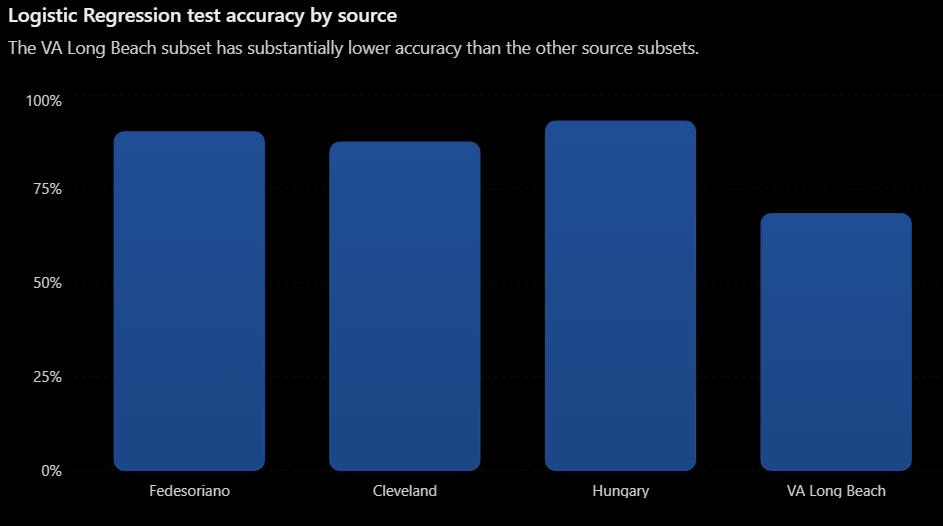

# **BUILD GraphSAGE USINGTHE SAME SPLIT**

# INSTALL PYTORCH **GEOMETRIC**

In [43]:
%pip -q install torch-geometric

# **BUILD GRAPH**

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Convert sparse/dense sklearn output into NumPy arrays
def to_dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

Xtr = to_dense_array(X_train_processed).astype(np.float32)
Xva = to_dense_array(X_val_processed).astype(np.float32)
Xte = to_dense_array(X_test_processed).astype(np.float32)

ytr = y_train.to_numpy(dtype=np.int64)
yva = y_val.to_numpy(dtype=np.int64)
yte = y_test.to_numpy(dtype=np.int64)

# Similarity graph:
# Each node connects to its k most similar training nodes.
# No validation/test labels are used to build edges.

def make_knn_edges(query_x, reference_x, k=7):
    similarities = cosine_similarity(query_x, reference_x)
    edges = []

    k = min(k, reference_x.shape[0])

    for i in range(query_x.shape[0]):
        nearest = np.argpartition(similarities[i], -k)[-k:]
        for j in nearest:
            edges.append((j, i))  # reference node -> query node

    return torch.tensor(edges, dtype=torch.long).t().contiguous()

# Train graph: training nodes connect among themselves
train_edges = make_knn_edges(Xtr, Xtr, k=7)

# Remove self-loops from the training graph
train_edges = train_edges[:, train_edges[0] != train_edges[1]]

# Validation/test nodes receive messages from training nodes only
val_edges_local = make_knn_edges(Xva, Xtr, k=7)
test_edges_local = make_knn_edges(Xte, Xtr, k=7)

n_train = len(Xtr)
n_val = len(Xva)
n_test = len(Xte)

# One disjoint graph containing train, validation, and test features.
# Edges only flow from training nodes to training/held-out query nodes.
val_edges = val_edges_local.clone()
val_edges[1] += n_train

test_edges = test_edges_local.clone()
test_edges[1] += n_train + n_val

# Combine edges with node offsets
all_edges = torch.cat([
    train_edges,
    val_edges,
    test_edges
], dim=1)

# Feature matrix and labels
X_all = np.vstack([Xtr, Xva, Xte])
y_all = np.concatenate([ytr, yva, yte])

data = Data(
    x=torch.tensor(X_all, dtype=torch.float32),
    edge_index=all_edges,
    y=torch.tensor(y_all, dtype=torch.long)
)

train_idx = torch.arange(0, n_train)
val_idx = torch.arange(n_train, n_train + n_val)
test_idx = torch.arange(n_train + n_val, n_train + n_val + n_test)

print(data)
print("Train nodes:", len(train_idx))
print("Validation nodes:", len(val_idx))
print("Test nodes:", len(test_idx))
print("Total directed edges:", data.edge_index.shape[1])

# Check that held-out nodes never send messages to other nodes
src, dst = data.edge_index
print("Validation nodes used as edge sources:", int(((src >= n_train) & (src < n_train+n_val)).sum()))
print("Test nodes used as edge sources:", int((src >= n_train+n_val).sum()))


Data(x=[1280, 21], edge_index=[2, 8137], y=[1280])
Train nodes: 823
Validation nodes: 201
Test nodes: 256
Total directed edges: 8137
Validation nodes used as edge sources: 0
Test nodes used as edge sources: 0


# **TRAIN GraphSAGE**

In [45]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

train_idx = train_idx.to(device)
val_idx = val_idx.to(device)
test_idx = test_idx.to(device)

class GraphSAGE(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

model = GraphSAGE(
    input_dim=data.x.shape[1],
    hidden_dim=32,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=0.005
)

best_val_f1 = -1
best_state = None
best_epoch = 0
patience = 20
wait = 0
max_epochs = 200

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    loss = F.cross_entropy(logits[train_idx], data.y[train_idx])

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        val_probs = torch.softmax(logits[val_idx], dim=1)[:, 1].cpu().numpy()
        val_preds = (val_probs >= 0.5).astype(int)
        val_true = data.y[val_idx].cpu().numpy()

        val_f1 = f1_score(val_true, val_preds, zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss {loss.item():.4f} | "
            f"Validation F1 {val_f1:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print("\nBest epoch:", best_epoch)
print("Best validation F1:", round(best_val_f1, 4))

Epoch 010 | Train loss 0.4293 | Validation F1 0.8144
Epoch 020 | Train loss 0.3950 | Validation F1 0.8100
Epoch 030 | Train loss 0.3592 | Validation F1 0.8182
Epoch 040 | Train loss 0.3384 | Validation F1 0.8081
Epoch 050 | Train loss 0.3059 | Validation F1 0.8265
Epoch 060 | Train loss 0.2779 | Validation F1 0.8325
Epoch 070 | Train loss 0.2603 | Validation F1 0.8325
Early stopping at epoch 75

Best epoch: 55
Best validation F1: 0.85


# **EVALUATE ON TEST SET**

In [46]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    test_probs_gnn = torch.softmax(logits[test_idx], dim=1)[:, 1].cpu().numpy()
    test_preds_gnn = (test_probs_gnn >= 0.5).astype(int)

print("===== GraphSAGE: Test Set =====")
print("Accuracy :", round(accuracy_score(yte, test_preds_gnn), 4))
print("Precision:", round(precision_score(yte, test_preds_gnn, zero_division=0), 4))
print("Recall   :", round(recall_score(yte, test_preds_gnn, zero_division=0), 4))
print("F1       :", round(f1_score(yte, test_preds_gnn, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(yte, test_probs_gnn), 4))

print("\nConfusion matrix:")
print(confusion_matrix(yte, test_preds_gnn))
print("\nClassification report:")
print(classification_report(yte, test_preds_gnn, zero_division=0))

===== GraphSAGE: Test Set =====
Accuracy : 0.8125
Precision: 0.7153
Recall   : 0.9159
F1       : 0.8033
ROC-AUC  : 0.9239

Confusion matrix:
[[110  39]
 [  9  98]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       149
           1       0.72      0.92      0.80       107

    accuracy                           0.81       256
   macro avg       0.82      0.83      0.81       256
weighted avg       0.84      0.81      0.81       256



# **INSPECT VALIDATION RESULTS**

In [47]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    val_probs_gnn = (
        torch.softmax(logits[val_idx], dim=1)[:, 1]
        .cpu().numpy()
    )

val_true_gnn = yva

print("GraphSAGE validation ROC-AUC:",
      round(roc_auc_score(val_true_gnn, val_probs_gnn), 4))

print("\nThreshold comparison on validation set:")

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    preds = (val_probs_gnn >= threshold).astype(int)

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision_score(val_true_gnn, preds, zero_division=0):.3f} | "
        f"Recall={recall_score(val_true_gnn, preds, zero_division=0):.3f} | "
        f"F1={f1_score(val_true_gnn, preds, zero_division=0):.3f} | "
        f"Accuracy={accuracy_score(val_true_gnn, preds):.3f}"
    )

GraphSAGE validation ROC-AUC: 0.8993

Threshold comparison on validation set:
Threshold=0.30 | Precision=0.723 | Recall=0.935 | F1=0.815 | Accuracy=0.806
Threshold=0.35 | Precision=0.729 | Recall=0.935 | F1=0.819 | Accuracy=0.811
Threshold=0.40 | Precision=0.754 | Recall=0.935 | F1=0.835 | Accuracy=0.831
Threshold=0.45 | Precision=0.775 | Recall=0.935 | F1=0.847 | Accuracy=0.846
Threshold=0.50 | Precision=0.787 | Recall=0.924 | F1=0.850 | Accuracy=0.851
Threshold=0.55 | Precision=0.785 | Recall=0.913 | F1=0.844 | Accuracy=0.846
Threshold=0.60 | Precision=0.800 | Recall=0.826 | F1=0.813 | Accuracy=0.826


# **TUNE THE GRAPH SIZE**

In [48]:
def build_graph_for_k(k):
    tr_edges = make_knn_edges(Xtr, Xtr, k=k)
    tr_edges = tr_edges[:, tr_edges[0] != tr_edges[1]]

    va_edges = make_knn_edges(Xva, Xtr, k=k)
    va_edges[1] += n_train

    te_edges = make_knn_edges(Xte, Xtr, k=k)
    te_edges[1] += n_train + n_val

    edges = torch.cat([tr_edges, va_edges, te_edges], dim=1)

    return Data(
        x=torch.tensor(X_all, dtype=torch.float32),
        edge_index=edges,
        y=torch.tensor(y_all, dtype=torch.long)
    ).to(device)


results = []
best_k = None
best_k_f1 = -1
best_k_state = None
best_k_epoch = None

for k in [3, 5, 7, 10]:
    graph = build_graph_for_k(k)

    torch.manual_seed(42)

    candidate = GraphSAGE(
        input_dim=graph.x.shape[1],
        hidden_dim=32,
        dropout=0.2
    ).to(device)

    opt = torch.optim.Adam(
        candidate.parameters(),
        lr=0.01,
        weight_decay=0.005
    )

    local_best_f1 = -1
    local_best_state = None
    local_best_epoch = 0
    patience_counter = 0

    for epoch in range(1, 201):
        candidate.train()
        opt.zero_grad()

        logits = candidate(graph.x, graph.edge_index)
        loss = F.cross_entropy(logits[train_idx], graph.y[train_idx])
        loss.backward()
        opt.step()

        candidate.eval()
        with torch.no_grad():
            logits = candidate(graph.x, graph.edge_index)
            probs = torch.softmax(logits[val_idx], dim=1)[:, 1].cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            true = graph.y[val_idx].cpu().numpy()
            score = f1_score(true, preds, zero_division=0)

        if score > local_best_f1:
            local_best_f1 = score
            local_best_epoch = epoch
            local_best_state = {
                name: value.detach().cpu().clone()
                for name, value in candidate.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 20:
            break

    results.append({
        "k": k,
        "best_epoch": local_best_epoch,
        "validation_f1": local_best_f1
    })

    print(
        f"k={k}: best epoch={local_best_epoch}, "
        f"validation F1={local_best_f1:.4f}"
    )

    if local_best_f1 > best_k_f1:
        best_k_f1 = local_best_f1
        best_k = k
        best_k_state = local_best_state
        best_k_epoch = local_best_epoch

print("\nSelected k:", best_k)
print("Selected validation F1:", round(best_k_f1, 4))

k=3: best epoch=23, validation F1=0.8485
k=5: best epoch=51, validation F1=0.8528
k=7: best epoch=55, validation F1=0.8500
k=10: best epoch=51, validation F1=0.8458

Selected k: 5
Selected validation F1: 0.8528


# **EVALUATION WITH K = 5**

In [49]:
selected_graph = build_graph_for_k(best_k)

selected_model = GraphSAGE(
    input_dim=selected_graph.x.shape[1],
    hidden_dim=32,
    dropout=0.2
).to(device)

selected_model.load_state_dict(best_k_state)
selected_model.eval()

with torch.no_grad():
    logits = selected_model(
        selected_graph.x,
        selected_graph.edge_index
    )

    test_probs_selected = (
        torch.softmax(logits[test_idx], dim=1)[:, 1]
        .cpu().numpy()
    )

    test_preds_selected = (
        test_probs_selected >= 0.5
    ).astype(int)

print(f"Selected k: {best_k}")
print(f"Selected epoch: {best_k_epoch}")
print(f"Validation F1: {best_k_f1:.4f}")

print("\n===== Selected GraphSAGE: Test Set =====")
print("Accuracy :", round(accuracy_score(yte, test_preds_selected), 4))
print("Precision:", round(precision_score(yte, test_preds_selected, zero_division=0), 4))
print("Recall   :", round(recall_score(yte, test_preds_selected, zero_division=0), 4))
print("F1       :", round(f1_score(yte, test_preds_selected, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(yte, test_probs_selected), 4))

print("\nConfusion matrix:")
print(confusion_matrix(yte, test_preds_selected))

Selected k: 5
Selected epoch: 51
Validation F1: 0.8528

===== Selected GraphSAGE: Test Set =====
Accuracy : 0.8477
Precision: 0.7537
Recall   : 0.9439
F1       : 0.8382
ROC-AUC  : 0.9429

Confusion matrix:
[[116  33]
 [  6 101]]


# **COMPARE GRAPH BUILDING METHODS**

In [50]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from torch_geometric.data import Data

def make_edges_metric(query_x, reference_x, k=5, metric="cosine",
                      mutual=False):
    if metric == "cosine":
        similarities = cosine_similarity(query_x, reference_x)
    elif metric == "euclidean":
        distances = euclidean_distances(query_x, reference_x)
        # Larger score means closer neighbor
        similarities = -distances
    else:
        raise ValueError("Unknown metric")

    k = min(k, len(reference_x))
    neighbor_sets = []

    for i in range(len(query_x)):
        nearest = np.argpartition(similarities[i], -k)[-k:]
        neighbor_sets.append(set(nearest.tolist()))

    edges = []
    for i, neighbors in enumerate(neighbor_sets):
        for j in neighbors:
            # For mutual kNN, both nodes must select each other.
            if mutual and i < len(reference_x):
                if i not in neighbor_sets[j]:
                    continue
            edges.append((j, i))

    if not edges:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(edges, dtype=torch.long).t().contiguous()


def build_graph_variant(k, metric, mutual=False):
    tr_edges = make_edges_metric(
        Xtr, Xtr, k=k, metric=metric, mutual=mutual
    )
    tr_edges = tr_edges[:, tr_edges[0] != tr_edges[1]]

    va_edges = make_edges_metric(
        Xva, Xtr, k=k, metric=metric
    )
    va_edges[1] += n_train

    te_edges = make_edges_metric(
        Xte, Xtr, k=k, metric=metric
    )
    te_edges[1] += n_train + n_val

    edges = torch.cat([tr_edges, va_edges, te_edges], dim=1)

    return Data(
        x=torch.tensor(X_all, dtype=torch.float32),
        edge_index=edges,
        y=torch.tensor(y_all, dtype=torch.long)
    ).to(device)


graph_configs = [
    (3, "cosine", False),
    (5, "cosine", False),
    (10, "cosine", False),
    (3, "euclidean", False),
    (5, "euclidean", False),
    (10, "euclidean", False),
    (5, "cosine", True),
]

graph_results = []

for k, metric, mutual in graph_configs:
    graph = build_graph_variant(k, metric, mutual)

    torch.manual_seed(42)
    candidate = GraphSAGE(
        input_dim=graph.x.shape[1],
        hidden_dim=32,
        dropout=0.2
    ).to(device)

    optimizer = torch.optim.Adam(
        candidate.parameters(),
        lr=0.01,
        weight_decay=0.005
    )

    best_f1 = -1
    best_auc = 0
    best_state = None
    wait = 0

    for epoch in range(1, 151):
        candidate.train()
        optimizer.zero_grad()

        logits = candidate(graph.x, graph.edge_index)
        loss = F.cross_entropy(
            logits[train_idx], graph.y[train_idx]
        )
        loss.backward()
        optimizer.step()

        candidate.eval()
        with torch.no_grad():
            logits = candidate(graph.x, graph.edge_index)
            probs = torch.softmax(
                logits[val_idx], dim=1
            )[:, 1].cpu().numpy()

        true = yva
        preds = (probs >= 0.5).astype(int)
        f1 = f1_score(true, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_auc = roc_auc_score(true, probs)
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in candidate.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= 20:
            break

    graph_results.append({
        "k": k,
        "metric": metric,
        "mutual_knn": mutual,
        "best_epoch": epoch - wait,
        "validation_f1": best_f1,
        "validation_roc_auc": best_auc,
        "state": best_state
    })

    print(
        f"k={k}, metric={metric}, mutual={mutual} | "
        f"val F1={best_f1:.4f}, AUC={best_auc:.4f}"
    )

print("\nRanked validation results:")
display(
    pd.DataFrame([
        {key: value for key, value in row.items() if key != "state"}
        for row in graph_results
    ]).sort_values(
        ["validation_f1", "validation_roc_auc"],
        ascending=False
    ).reset_index(drop=True).round(4)
)

k=3, metric=cosine, mutual=False | val F1=0.8485, AUC=0.8948
k=5, metric=cosine, mutual=False | val F1=0.8528, AUC=0.8959
k=10, metric=cosine, mutual=False | val F1=0.8458, AUC=0.9014
k=3, metric=euclidean, mutual=False | val F1=0.8400, AUC=0.8896
k=5, metric=euclidean, mutual=False | val F1=0.8426, AUC=0.8967
k=10, metric=euclidean, mutual=False | val F1=0.8182, AUC=0.8910
k=5, metric=cosine, mutual=True | val F1=0.8469, AUC=0.8996

Ranked validation results:


,k,metric,mutual_knn,best_epoch,validation_f1,validation_roc_auc
0,5,cosine,False,51,0.8528,0.8959
1,3,cosine,False,23,0.8485,0.8948
2,5,cosine,True,27,0.8469,0.8996
3,10,cosine,False,51,0.8458,0.9014
4,5,euclidean,False,18,0.8426,0.8967
5,3,euclidean,False,22,0.8400,0.8896
6,10,euclidean,False,7,0.8182,0.8910


# **IMPLEMENT THE GAT**

In [51]:
from torch_geometric.nn import GATConv
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import copy
import torch
import torch.nn.functional as F
import pandas as pd

class GAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=32, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(
            input_dim, hidden_dim,
            heads=heads, dropout=dropout
        )
        self.gat2 = GATConv(
            hidden_dim * heads, hidden_dim,
            heads=1, concat=False, dropout=dropout
        )
        self.classifier = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        return self.classifier(x)


# Use the existing cosine k=5 graph from the previous experiment.
# If `data` was overwritten during graph sweeps, rebuild it using
# the same cosine k=5 construction before running this cell.

gat = GAT(
    input_dim=data.x.shape[1],
    hidden_dim=32,
    heads=4,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    gat.parameters(),
    lr=0.005,
    weight_decay=0.005
)

best_val_f1 = -1
best_epoch = 0
best_state = None
patience = 20
wait = 0

for epoch in range(1, 201):
    gat.train()
    optimizer.zero_grad()

    logits = gat(data.x, data.edge_index)
    loss = F.cross_entropy(
        logits[train_idx], data.y[train_idx]
    )
    loss.backward()
    optimizer.step()

    gat.eval()
    with torch.no_grad():
        logits = gat(data.x, data.edge_index)
        val_probs = torch.softmax(
            logits[val_idx], dim=1
        )[:, 1].cpu().numpy()

    val_preds = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(yva, val_preds, zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_state = copy.deepcopy(gat.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break

gat.load_state_dict(best_state)
gat.eval()

with torch.no_grad():
    logits = gat(data.x, data.edge_index)
    val_probs = torch.softmax(
        logits[val_idx], dim=1
    )[:, 1].cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

print("Best epoch:", best_epoch)
print("Validation accuracy:", round(accuracy_score(yva, val_preds), 4))
print("Validation precision:", round(precision_score(yva, val_preds, zero_division=0), 4))
print("Validation recall:", round(recall_score(yva, val_preds, zero_division=0), 4))
print("Validation F1:", round(f1_score(yva, val_preds, zero_division=0), 4))
print("Validation ROC-AUC:", round(roc_auc_score(yva, val_probs), 4))

Best epoch: 34
Validation accuracy: 0.8408
Validation precision: 0.8191
Validation recall: 0.837
Validation F1: 0.828
Validation ROC-AUC: 0.8918


# **BUILD WEIGHTED-EDGE GCN**

In [52]:
import numpy as np
import pandas as pd
import copy
import torch
import torch.nn.functional as F

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


# 1. Build weighted edges: training patients -> query patients.
# Similarity is converted from [-1, 1] to [0, 1].
def make_weighted_edges(query_x, reference_x, k=5):
    sims = cosine_similarity(query_x, reference_x)
    k = min(k, len(reference_x))

    edges = []
    weights = []

    for i in range(len(query_x)):
        nearest = np.argpartition(sims[i], -k)[-k:]

        for j in nearest:
            edges.append((j, i))
            weights.append((sims[i, j] + 1.0) / 2.0)

    edge_index = torch.tensor(
        edges, dtype=torch.long
    ).t().contiguous()

    edge_weight = torch.tensor(
        weights, dtype=torch.float32
    )

    return edge_index, edge_weight


# 2. Stack features in train, validation, test order.
X_all = np.vstack([Xtr, Xva, Xte]).astype(np.float32)

n_train = len(Xtr)
n_val = len(Xva)
n_test = len(Xte)

train_idx = torch.arange(n_train, dtype=torch.long)
val_idx = torch.arange(
    n_train, n_train + n_val, dtype=torch.long
)
test_idx = torch.arange(
    n_train + n_val, n_train + n_val + n_test,
    dtype=torch.long
)

y_all = np.concatenate([y_train, yva, y_test])
y_tensor = torch.tensor(y_all, dtype=torch.long)


# 3. Construct a k=5 weighted graph.
k = 5

train_edges, train_weights = make_weighted_edges(Xtr, Xtr, k)
# Remove explicit self-edges; GCNConv adds self-loops itself.
keep = train_edges[0] != train_edges[1]
train_edges = train_edges[:, keep]
train_weights = train_weights[keep]

val_edges, val_weights = make_weighted_edges(Xva, Xtr, k)
val_edges[1] += n_train

test_edges, test_weights = make_weighted_edges(Xte, Xtr, k)
test_edges[1] += n_train + n_val

edge_index = torch.cat(
    [train_edges, val_edges, test_edges], dim=1
)
edge_weight = torch.cat(
    [train_weights, val_weights, test_weights]
)

gcn_data = Data(
    x=torch.tensor(X_all, dtype=torch.float32),
    edge_index=edge_index,
    y=y_tensor,
    edge_weight=edge_weight
).to(device)

train_idx = train_idx.to(device)
val_idx = val_idx.to(device)
test_idx = test_idx.to(device)


# 4. Define a two-layer weighted GCN.
class WeightedGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index, edge_weight):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_weight))
        return self.classifier(x)


# 5. Train with early stopping on validation F1.
torch.manual_seed(42)

gcn = WeightedGCN(
    input_dim=gcn_data.x.shape[1],
    hidden_dim=32,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(
    gcn.parameters(),
    lr=0.005,
    weight_decay=0.005
)

best_val_f1 = -1
best_epoch = 0
best_state = None
wait = 0
patience = 20

for epoch in range(1, 201):
    gcn.train()
    optimizer.zero_grad()

    logits = gcn(
        gcn_data.x,
        gcn_data.edge_index,
        gcn_data.edge_weight
    )

    loss = F.cross_entropy(
        logits[train_idx], gcn_data.y[train_idx]
    )
    loss.backward()
    optimizer.step()

    gcn.eval()
    with torch.no_grad():
        logits = gcn(
            gcn_data.x,
            gcn_data.edge_index,
            gcn_data.edge_weight
        )
        val_probs = torch.softmax(
            logits[val_idx], dim=1
        )[:, 1].cpu().numpy()

    val_preds = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(yva, val_preds, zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_state = copy.deepcopy(gcn.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break


# 6. Report validation metrics only.
gcn.load_state_dict(best_state)
gcn.eval()

with torch.no_grad():
    logits = gcn(
        gcn_data.x,
        gcn_data.edge_index,
        gcn_data.edge_weight
    )
    val_probs = torch.softmax(
        logits[val_idx], dim=1
    )[:, 1].cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

print("Best epoch:", best_epoch)
print("Validation accuracy:", round(accuracy_score(yva, val_preds), 4))
print("Validation precision:", round(precision_score(yva, val_preds, zero_division=0), 4))
print("Validation recall:", round(recall_score(yva, val_preds, zero_division=0), 4))
print("Validation F1:", round(f1_score(yva, val_preds, zero_division=0), 4))
print("Validation ROC-AUC:", round(roc_auc_score(yva, val_probs), 4))

Best epoch: 27
Validation accuracy: 0.8209
Validation precision: 0.7857
Validation recall: 0.837
Validation F1: 0.8105
Validation ROC-AUC: 0.8821


# **REGENERATING PROBABILITIES**

In [53]:
model.eval()

with torch.no_grad():
    sage_logits = model(data.x, data.edge_index)
    sage_val_probs = torch.softmax(
        sage_logits[val_idx], dim=1
    )[:, 1].cpu().numpy()

print("Validation probabilities:", len(sage_val_probs))
print("Validation labels:", len(yva))
print("Probabilities regenerated successfully.")

Validation probabilities: 201
Validation labels: 201
Probabilities regenerated successfully.


# **RERUN GraphSAGE**

In [54]:

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

threshold_results = []

for threshold in np.arange(0.30, 0.701, 0.025):
    preds = (sage_val_probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 3),
        "accuracy": accuracy_score(yva, preds),
        "precision": precision_score(yva, preds, zero_division=0),
        "recall": recall_score(yva, preds, zero_division=0),
        "f1": f1_score(yva, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)

print("Top thresholds by validation F1:")
display(
    threshold_df.sort_values(
        ["f1", "accuracy"], ascending=False
    ).head(10).round(4)
)

print("Top thresholds by validation accuracy:")
display(
    threshold_df.sort_values(
        ["accuracy", "f1"], ascending=False
    ).head(10).round(4)
)

Top thresholds by validation F1:


,threshold,accuracy,precision,recall,f1
8,0.500,0.8507,0.7870,0.9239,0.8500
9,0.525,0.8507,0.7870,0.9239,0.8500
6,0.450,0.8458,0.7748,0.9348,0.8473
10,0.550,0.8458,0.7850,0.9130,0.8442
7,0.475,0.8408,0.7727,0.9239,0.8416
11,0.575,0.8458,0.7961,0.8913,0.8410
5,0.425,0.8358,0.7611,0.9348,0.8390
4,0.400,0.8308,0.7544,0.9348,0.8350
3,0.375,0.8209,0.7414,0.9348,0.8269
2,0.350,0.8109,0.7288,0.9348,0.8190


Top thresholds by validation accuracy:


,threshold,accuracy,precision,recall,f1
8,0.500,0.8507,0.7870,0.9239,0.8500
9,0.525,0.8507,0.7870,0.9239,0.8500
6,0.450,0.8458,0.7748,0.9348,0.8473
10,0.550,0.8458,0.7850,0.9130,0.8442
11,0.575,0.8458,0.7961,0.8913,0.8410
7,0.475,0.8408,0.7727,0.9239,0.8416
5,0.425,0.8358,0.7611,0.9348,0.8390
4,0.400,0.8308,0.7544,0.9348,0.8350
12,0.600,0.8259,0.8000,0.8261,0.8128
3,0.375,0.8209,0.7414,0.9348,0.8269


# **CONTROLLED GRAPH HYPERPARAMETER SEARCH**

In [55]:
print("GraphSAGE model variable:", "model" in globals())
print("GraphSAGE class:", "GraphSAGE" in globals())
print("Original graph variable:", "data" in globals())
print("Weighted GCN graph:", "gcn_data" in globals())
print("Train/validation indices:", "train_idx" in globals(), "val_idx" in globals())
print("Feature matrix:", "X_all" in globals())

GraphSAGE model variable: True
GraphSAGE class: True
Original graph variable: True
Weighted GCN graph: True
Train/validation indices: True True
Feature matrix: True


# **CHECK THE GRAPH AND INDICES**

In [56]:

print("Graph node count:", data.x.shape[0])
print("Graph feature count:", data.x.shape[1])
print("Train nodes:", len(train_idx))
print("Validation nodes:", len(val_idx))
print("Test nodes:", len(test_idx))
print("GraphSAGE class:", GraphSAGE)
print("Current model class:", type(model).__name__)
print("Feature matrix shape:", X_all.shape)

Graph node count: 1280
Graph feature count: 21
Train nodes: 823
Validation nodes: 201
Test nodes: 256
GraphSAGE class: <class '__main__.GraphSAGE'>
Current model class: GraphSAGE
Feature matrix shape: (1280, 21)


# **GraphSAGE HYPERPARAMETER SEARCH**

In [57]:
import copy
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Confirm graph/split sizes before training
assert data.x.shape[0] == 1280
assert len(train_idx) == 823
assert len(val_idx) == 201
assert len(test_idx) == 256

# Confirm GraphSAGE's constructor and forward method match this call:
# GraphSAGE(input_dim, hidden_dim=..., dropout=...)
# model(x, edge_index) -> logits of shape [num_nodes, 2]

configs = list(itertools.product(
    [16, 32, 64],       # hidden dimension
    [0.2, 0.4],          # dropout
    [0.005, 0.01],       # learning rate
))

# Keep the first 12 combinations for a manageable first search
configs = configs[:12]

search_results = []
best_search_f1 = -1
best_search_state = None
best_search_config = None

for run_id, (hidden_dim, dropout, lr) in enumerate(configs, start=1):
    torch.manual_seed(1000 + run_id)

    candidate = GraphSAGE(
        input_dim=data.x.shape[1],
        hidden_dim=hidden_dim,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        candidate.parameters(),
        lr=lr,
        weight_decay=0.005
    )

    best_f1 = -1
    best_auc = 0
    best_epoch = 0
    best_state = None
    patience = 20
    wait = 0

    for epoch in range(1, 151):
        candidate.train()
        optimizer.zero_grad()

        logits = candidate(data.x, data.edge_index)
        loss = F.cross_entropy(
            logits[train_idx], data.y[train_idx]
        )
        loss.backward()
        optimizer.step()

        candidate.eval()
        with torch.no_grad():
            logits = candidate(data.x, data.edge_index)
            probs = torch.softmax(
                logits[val_idx], dim=1
            )[:, 1].cpu().numpy()

        preds = (probs >= 0.5).astype(int)
        val_f1 = f1_score(yva, preds, zero_division=0)
        val_auc = roc_auc_score(yva, probs)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_auc = val_auc
            best_epoch = epoch
            best_state = copy.deepcopy(candidate.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    search_results.append({
        "run": run_id,
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "learning_rate": lr,
        "best_epoch": best_epoch,
        "val_f1": best_f1,
        "val_auc": best_auc,
        "state": best_state
    })

    print(
        f"{run_id:02d}/12 | hidden={hidden_dim}, dropout={dropout}, "
        f"lr={lr} | F1={best_f1:.4f}, AUC={best_auc:.4f}"
    )

# Display ranked results
results_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != "state"}
    for row in search_results
])

display(
    results_df.sort_values(
        ["val_f1", "val_auc"], ascending=False
    ).reset_index(drop=True).round(4)
)

# Save the selected validation-best checkpoint in memory
winner = max(
    search_results,
    key=lambda r: (r["val_f1"], r["val_auc"])
)

best_search_config = {
    "hidden_dim": winner["hidden_dim"],
    "dropout": winner["dropout"],
    "learning_rate": winner["learning_rate"],
    "weight_decay": 0.005,
    "best_epoch": winner["best_epoch"]
}
best_search_state = winner["state"]

print("\nSelected configuration:", best_search_config)
print("Best validation F1:", round(winner["val_f1"], 4))
print("Best validation ROC-AUC:", round(winner["val_auc"], 4))

01/12 | hidden=16, dropout=0.2, lr=0.005 | F1=0.8290, AUC=0.8906
02/12 | hidden=16, dropout=0.2, lr=0.01 | F1=0.8351, AUC=0.8976
03/12 | hidden=16, dropout=0.4, lr=0.005 | F1=0.8290, AUC=0.8994
04/12 | hidden=16, dropout=0.4, lr=0.01 | F1=0.8449, AUC=0.8967
05/12 | hidden=32, dropout=0.2, lr=0.005 | F1=0.8351, AUC=0.8944
06/12 | hidden=32, dropout=0.2, lr=0.01 | F1=0.8466, AUC=0.9021
07/12 | hidden=32, dropout=0.4, lr=0.005 | F1=0.8377, AUC=0.8961
08/12 | hidden=32, dropout=0.4, lr=0.01 | F1=0.8421, AUC=0.9001
09/12 | hidden=64, dropout=0.2, lr=0.005 | F1=0.8469, AUC=0.8916
10/12 | hidden=64, dropout=0.2, lr=0.01 | F1=0.8410, AUC=0.8987
11/12 | hidden=64, dropout=0.4, lr=0.005 | F1=0.8400, AUC=0.9038
12/12 | hidden=64, dropout=0.4, lr=0.01 | F1=0.8426, AUC=0.8985


,run,hidden_dim,dropout,learning_rate,best_epoch,val_f1,val_auc
0,9,64,0.2,0.005,14,0.8469,0.8916
1,6,32,0.2,0.010,41,0.8466,0.9021
2,4,16,0.4,0.010,26,0.8449,0.8967
3,12,64,0.4,0.010,22,0.8426,0.8985
4,8,32,0.4,0.010,37,0.8421,0.9001
5,10,64,0.2,0.010,10,0.8410,0.8987
6,11,64,0.4,0.005,27,0.8400,0.9038
7,7,32,0.4,0.005,31,0.8377,0.8961
8,2,16,0.2,0.010,21,0.8351,0.8976
9,5,32,0.2,0.005,30,0.8351,0.8944



Selected configuration: {'hidden_dim': 64, 'dropout': 0.2, 'learning_rate': 0.005, 'weight_decay': 0.005, 'best_epoch': 14}
Best validation F1: 0.8469
Best validation ROC-AUC: 0.8916


# **MULTI-SEED GraphSAGE STABILITY EXPERIMENT**

In [58]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.metrics import f1_score, roc_auc_score

experiments = [
    {"name": "baseline_32", "hidden": 32, "dropout": 0.2, "lr": 0.01},
    {"name": "alternative_64", "hidden": 64, "dropout": 0.4, "lr": 0.005},
]

seeds = [11, 22, 33, 44, 55]
stability_results = []

for cfg in experiments:
    for seed in seeds:
        torch.manual_seed(seed)

        candidate = GraphSAGE(
            input_dim=data.x.shape[1],
            hidden_dim=cfg["hidden"],
            dropout=cfg["dropout"]
        ).to(device)

        optimizer = torch.optim.Adam(
            candidate.parameters(),
            lr=cfg["lr"],
            weight_decay=0.005
        )

        best_f1 = -1
        best_auc = 0
        best_state = None
        wait = 0

        for epoch in range(1, 151):
            candidate.train()
            optimizer.zero_grad()

            logits = candidate(data.x, data.edge_index)
            loss = F.cross_entropy(
                logits[train_idx], data.y[train_idx]
            )
            loss.backward()
            optimizer.step()

            candidate.eval()
            with torch.no_grad():
                logits = candidate(data.x, data.edge_index)
                probs = torch.softmax(
                    logits[val_idx], dim=1
                )[:, 1].cpu().numpy()

            preds = (probs >= 0.5).astype(int)
            val_f1 = f1_score(yva, preds, zero_division=0)
            val_auc = roc_auc_score(yva, probs)

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_auc = val_auc
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in candidate.state_dict().items()
                }
                wait = 0
            else:
                wait += 1

            if wait >= 20:
                break

        stability_results.append({
            "configuration": cfg["name"],
            "seed": seed,
            "best_epoch": epoch - wait,
            "validation_f1": best_f1,
            "validation_auc": best_auc
        })

stability_df = pd.DataFrame(stability_results)

print("Results for each seed:")
display(stability_df.round(4))

print("Mean and standard deviation:")
display(
    stability_df.groupby("configuration")[
        ["validation_f1", "validation_auc"]
    ].agg(["mean", "std"]).round(4)
)

Results for each seed:


,configuration,seed,best_epoch,validation_f1,validation_auc
0,baseline_32,11,16,0.8404,0.8983
1,baseline_32,22,10,0.8254,0.8938
2,baseline_32,33,31,0.8308,0.9001
3,baseline_32,44,26,0.8367,0.9006
4,baseline_32,55,14,0.8377,0.8930
5,alternative_64,11,23,0.8300,0.9015
6,alternative_64,22,12,0.8387,0.8932
7,alternative_64,33,21,0.8290,0.8979
8,alternative_64,44,14,0.8290,0.8874
9,alternative_64,55,43,0.8454,0.9007


Mean and standard deviation:


validation_f1         validation_auc        
                        mean     std           mean     std
configuration                                              
alternative_64        0.8344  0.0073         0.8961  0.0058
baseline_32           0.8342  0.0061         0.8971  0.0035

# **ALTERNATIVE EXPERIMENT**

# **IMPROVED FEATURE EXTRACTION TO PRODUCE BETTER RESULTS**

In [59]:
import pandas as pd
import numpy as np
from IPython.display import display

# Load the original dataset
df_audit = pd.read_csv("/content/heart_disease_whole.csv")

print("Dataset shape:", df_audit.shape)
print("\nColumns:")
print(df_audit.columns.tolist())

print("\nFirst 5 rows:")
display(df_audit.head())

print("\nTarget distribution:")
display(df_audit["target"].value_counts(dropna=False))

print("\nRecords per source:")
display(
    df_audit["source"]
    .value_counts(dropna=False)
    .rename("record_count")
    .to_frame()
)

Dataset shape: (2283, 15)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63,1,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,uci_multi_cleveland
1,67,1,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,uci_multi_cleveland
2,67,1,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,uci_multi_cleveland
3,37,1,3,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,uci_multi_cleveland
4,41,0,2,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,uci_multi_cleveland



Target distribution:


,count
target,
1,1222
0,1061



Records per source:


,record_count
source,
fedesoriano_heart,760
uci_multi_cleveland,304
heart_disease_1048,303
kaggle_heart_1025,302
uci_multi_hungary,292
uci_multi_va long beach,199
uci_multi_switzerland,123


# **HANDLING MISSING VALUES**

In [60]:
# 1. Missing values by feature
missing = pd.DataFrame({
    "missing_count": df_audit.isna().sum(),
    "missing_percent": (
        df_audit.isna().mean() * 100
    ).round(2)
}).sort_values("missing_percent", ascending=False)

print("=== Missing values ===")
display(missing)

# 2. Missingness by source
print("=== Missingness by source (%) ===")
display(
    (df_audit.groupby("source", dropna=False)
     .apply(lambda g: g.isna().mean() * 100, include_groups=False)
     .round(1))
)

# 3. Duplicate rows
print("=== Duplicate records ===")
print("Exact duplicate rows:", df_audit.duplicated().sum())

# 4. Target consistency
print("=== Target values by source ===")
display(pd.crosstab(
    df_audit["source"],
    df_audit["target"],
    margins=True,
    dropna=False
))

# 5. Basic numeric ranges
print("=== Numeric feature ranges ===")
display(df_audit.describe().T)

=== Missing values ===


,missing_count,missing_percent
ca,1672,73.24
thal,1547,67.76
chol,352,15.42
slope,307,13.45
fbs,90,3.94
oldpeak,62,2.72
trestbps,60,2.63
thalach,55,2.41
exang,55,2.41
restecg,2,0.09


=== Missingness by source (%) ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
source,,,,,,,,,,,,,,
fedesoriano_heart,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0
heart_disease_1048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0
kaggle_heart_1025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
uci_multi_cleveland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,1.6,1.0,0.0
uci_multi_hungary,0.0,0.0,0.0,0.3,7.5,2.7,0.3,0.3,0.3,0.0,64.4,99.0,90.4,0.0
uci_multi_switzerland,0.0,0.0,0.0,1.6,100.0,61.0,0.8,0.8,0.8,4.9,13.8,95.9,42.3,0.0
uci_multi_va long beach,0.0,0.0,0.0,28.6,28.1,3.5,0.0,26.6,26.6,28.1,50.8,99.0,82.9,0.0


=== Duplicate records ===
Exact duplicate rows: 0
=== Target values by source ===


target,0,1,All
source,,,
fedesoriano_heart,375,385,760
heart_disease_1048,138,165,303
kaggle_heart_1025,138,164,302
uci_multi_cleveland,165,139,304
uci_multi_hungary,186,106,292
uci_multi_switzerland,8,115,123
uci_multi_va long beach,51,148,199
All,1061,1222,2283


=== Numeric feature ranges ===


,count,mean,std,min,25%,50%,75%,max
age,2283.0,53.649584,9.401775,28.0,47.0,54.0,60.0,77.0
sex,2283.0,0.756899,0.429050,0.0,1.0,1.0,1.0,1.0
cp,2283.0,2.889619,1.109315,1.0,2.0,3.0,4.0,4.0
trestbps,2223.0,131.859649,18.028158,80.0,120.0,130.0,140.0,200.0
chol,1931.0,245.362506,56.370482,85.0,209.0,239.0,275.0,603.0
fbs,2193.0,0.186959,0.389967,0.0,0.0,0.0,0.0,1.0
restecg,2281.0,0.597545,0.756419,0.0,0.0,0.0,1.0,2.0
thalach,2228.0,141.304309,25.575089,60.0,122.0,143.0,161.0,202.0
exang,2228.0,0.354129,0.478356,0.0,0.0,0.0,1.0,1.0
oldpeak,2221.0,0.868393,1.093111,-2.6,0.0,0.5,1.5,6.2


# **CHECK**

In [61]:
profile_cols = [
    "age", "sex", "cp", "trestbps",
    "chol", "thalach", "exang", "oldpeak"
]

required = profile_cols + ["target", "source"]
missing_cols = [c for c in required if c not in df_audit.columns]

if missing_cols:
    print("Missing expected columns:", missing_cols)
else:
    # Only compare profiles with all grouping features present
    profiles = df_audit.dropna(subset=profile_cols).copy()

    # A profile is conflicting if its target has more than one value
    profile_stats = (
        profiles.groupby(profile_cols, dropna=False)
        .agg(
            row_count=("target", "size"),
            label_count=("target", "nunique"),
            labels=("target", lambda s: tuple(sorted(s.unique()))),
            sources=("source", lambda s: tuple(sorted(s.astype(str).unique())))
        )
        .reset_index()
    )

    conflicts = profile_stats[profile_stats["label_count"] > 1]

    print("Complete-profile rows:", len(profiles))
    print("Unique clinical profiles:", len(profile_stats))
    print("Conflicting profiles:", len(conflicts))
    print(
        "Rows belonging to conflicting profiles:",
        profiles.set_index(profile_cols).index.isin(
            conflicts.set_index(profile_cols).index
        ).sum()
    )

    display(conflicts.head(20))

Complete-profile rows: 1885
Unique clinical profiles: 911
Conflicting profiles: 136
Rows belonging to conflicting profiles: 544


,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,row_count,label_count,labels,sources
2,29,1,2,130.0,204.0,202.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
13,34,0,2,118.0,210.0,192.0,0.0,0.7,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
28,35,1,2,122.0,192.0,174.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
39,37,0,3,120.0,215.0,170.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
45,37,1,3,130.0,250.0,187.0,0.0,3.5,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
52,38,1,3,138.0,175.0,173.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
60,39,0,3,94.0,199.0,179.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
62,39,0,3,138.0,220.0,152.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
70,39,1,3,140.0,321.0,182.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."
90,41,0,2,105.0,198.0,168.0,0.0,0.0,4,2,"(0, 1)","(fedesoriano_heart, heart_disease_1048, kaggle..."


# **CHECK PROFILES**

In [62]:
import pandas as pd
import numpy as np
from itertools import combinations

df = df_audit.copy()

profile_cols = [
    "age", "sex", "cp", "trestbps",
    "chol", "thalach", "exang", "oldpeak"
]

# A. Find matching profiles with conflicting target labels
profiles = df.dropna(subset=profile_cols).copy()

profile_groups = (
    profiles.groupby(profile_cols, dropna=False)
    .agg(
        rows=("target", "size"),
        n_labels=("target", "nunique"),
        labels=("target", lambda x: tuple(sorted(x.unique()))),
        sources=("source", lambda x: tuple(sorted(x.unique())))
    )
    .reset_index()
)

conflicts = profile_groups[profile_groups["n_labels"] > 1]

print("Unique complete profiles:", len(profile_groups))
print("Conflicting profiles:", len(conflicts))
print("Conflicting profiles by source combination:")
display(conflicts["sources"].value_counts().head(20).to_frame("profiles"))

# B. Inspect actual conflicting records
if len(conflicts) > 0:
    conflict_rows = profiles.merge(
        conflicts[profile_cols],
        on=profile_cols,
        how="inner"
    ).sort_values(profile_cols)

    print("Example conflicting records:")
    display(
        conflict_rows[
            profile_cols + ["target", "source"]
        ].head(40)
    )

# C. Check category codes used by each source
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

print("Category codes by source:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(
        df.groupby("source")[col]
        .apply(lambda s: sorted(s.dropna().unique().tolist()))
        .to_frame("observed_values")
    )

Unique complete profiles: 911
Conflicting profiles: 136
Conflicting profiles by source combination:


,profiles
sources,
"(fedesoriano_heart, heart_disease_1048, kaggle_heart_1025, uci_multi_cleveland)",136


Example conflicting records:


,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,target,source
60,29,1,2,130.0,204.0,202.0,0.0,0.0,0,uci_multi_cleveland
227,29,1,2,130.0,204.0,202.0,0.0,0.0,0,fedesoriano_heart
296,29,1,2,130.0,204.0,202.0,0.0,0.0,1,kaggle_heart_1025
432,29,1,2,130.0,204.0,202.0,0.0,0.0,1,heart_disease_1048
101,34,0,2,118.0,210.0,192.0,0.0,0.7,0,uci_multi_cleveland
195,34,0,2,118.0,210.0,192.0,0.0,0.7,0,fedesoriano_heart
272,34,0,2,118.0,210.0,192.0,0.0,0.7,1,kaggle_heart_1025
408,34,0,2,118.0,210.0,192.0,0.0,0.7,1,heart_disease_1048
127,35,1,2,122.0,192.0,174.0,0.0,0.0,0,uci_multi_cleveland
263,35,1,2,122.0,192.0,174.0,0.0,0.0,0,fedesoriano_heart


Category codes by source:

--- sex ---


...

,observed_values
source,
fedesoriano_heart,"[1.0, 2.0, 3.0]"
heart_disease_1048,"[0.0, 1.0, 2.0]"
kaggle_heart_1025,"[1.0, 2.0, 3.0]"
uci_multi_cleveland,"[1.0, 2.0, 3.0]"
uci_multi_hungary,"[1.0, 2.0, 3.0]"
uci_multi_switzerland,"[1.0, 2.0, 3.0]"
uci_multi_va long beach,"[1.0, 2.0, 3.0]"



--- ca ---


,observed_values
source,
fedesoriano_heart,[]
heart_disease_1048,[]
kaggle_heart_1025,"[0.0, 1.0, 2.0, 3.0, 4.0]"
uci_multi_cleveland,"[0.0, 1.0, 2.0, 3.0]"
uci_multi_hungary,[0.0]
uci_multi_switzerland,"[1.0, 2.0]"
uci_multi_va long beach,[0.0]



--- thal ---


,observed_values
source,
fedesoriano_heart,[]
heart_disease_1048,[]
kaggle_heart_1025,"[0.0, 1.0, 2.0, 3.0]"
uci_multi_cleveland,"[3.0, 6.0, 7.0]"
uci_multi_hungary,"[3.0, 6.0, 7.0]"
uci_multi_switzerland,"[3.0, 6.0, 7.0]"
uci_multi_va long beach,"[3.0, 6.0, 7.0]"


# **DATA CLEANING TO REMOVE THE INCONSISTENT DATA**

In [63]:
import pandas as pd

# Preserve original data
df_original = df_audit.copy()

# Exclude the two provisionally unreliable sources
excluded_sources = [
    "heart_disease_1048",
    "kaggle_heart_1025"
]

df_clean = df_original[
    ~df_original["source"].isin(excluded_sources)
].copy()

print("Original rows:", len(df_original))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df_original) - len(df_clean))

print("\nRows retained per source:")
display(df_clean["source"].value_counts().to_frame("rows"))

print("\nTarget distribution:")
display(pd.crosstab(
    df_clean["source"],
    df_clean["target"],
    margins=True
))

print("\nOverall positive rate:", round(df_clean["target"].mean(), 4))

# Keep only the features used by the current model
feature_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope"
]

print("\nMissingness in model features (%):")
display(
    (df_clean[feature_cols].isna().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

# Confirm that the known four-source conflict pattern is gone
profile_cols = [
    "age", "sex", "cp", "trestbps",
    "chol", "thalach", "exang", "oldpeak"
]

complete = df_clean.dropna(subset=profile_cols)

conflict_check = (
    complete.groupby(profile_cols)["target"]
    .nunique()
)

print(
    "\nConflicting complete profiles remaining:",
    int((conflict_check > 1).sum())
)

Original rows: 2283
Cleaned rows: 1678
Rows removed: 605

Rows retained per source:


,rows
source,
fedesoriano_heart,760
uci_multi_cleveland,304
uci_multi_hungary,292
uci_multi_va long beach,199
uci_multi_switzerland,123



Target distribution:


target,0,1,All
source,,,
fedesoriano_heart,375,385,760
uci_multi_cleveland,165,139,304
uci_multi_hungary,186,106,292
uci_multi_switzerland,8,115,123
uci_multi_va long beach,51,148,199
All,785,893,1678



Overall positive rate: 0.5322

Missingness in model features (%):


,0
chol,20.98
slope,18.30
fbs,5.36
oldpeak,3.69
trestbps,3.58
thalach,3.28
exang,3.28
restecg,0.12
cp,0.00
age,0.00



Conflicting complete profiles remaining: 0


# **REBUILD A LEAKAGE-RESISTANT SPLIT**

In [64]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Features used to identify potentially duplicated patient profiles
profile_cols = [
    "age", "sex", "cp", "trestbps",
    "chol", "thalach", "exang", "oldpeak"
]

# Features used by the model (exclude target, source, ca, and thal)
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
feature_cols = continuous_cols + categorical_cols

# Keep only rows with complete profile keys for the leakage-resistant split
model_df = df_clean.dropna(subset=profile_cols).copy()
model_df = model_df.reset_index(drop=True)

# Matching profile keys get the same group ID
model_df["profile_group"] = (
    model_df.groupby(profile_cols, dropna=False, sort=False)
    .ngroup()
)

X_raw = model_df[feature_cols].copy()
y = model_df["target"].astype(int).to_numpy()
groups = model_df["profile_group"].to_numpy()

# Split 20% into test, then 20% of the remaining data into validation.
# This yields approximately 64% train / 16% validation / 20% test.
split1 = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=42
)
train_val_idx, test_idx = next(
    split1.split(X_raw, y, groups=groups)
)

split2 = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=43
)
train_rel_idx, val_rel_idx = next(
    split2.split(
        X_raw.iloc[train_val_idx],
        y[train_val_idx],
        groups=groups[train_val_idx]
    )
)

train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

# Verify that matching profile groups do not cross splits
train_groups = set(groups[train_idx])
val_groups = set(groups[val_idx])
test_groups = set(groups[test_idx])

print("Rows with complete profile keys:", len(model_df))
print("Unique profile groups:", len(np.unique(groups)))
print("\nSplit sizes:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTarget distribution (counts):")
for name, idx in [
    ("Train", train_idx),
    ("Validation", val_idx),
    ("Test", test_idx)
]:
    counts = pd.Series(y[idx]).value_counts().sort_index()
    print(
        f"{name}: {counts.to_dict()}, "
        f"positive rate={y[idx].mean():.4f}"
    )

print("\nGroup overlap checks:")
print("Train ∩ Validation:", len(train_groups & val_groups))
print("Train ∩ Test:", len(train_groups & test_groups))
print("Validation ∩ Test:", len(val_groups & test_groups))

print("\nRows per source in each split:")
for name, idx in [
    ("Train", train_idx),
    ("Validation", val_idx),
    ("Test", test_idx)
]:
    print(f"\n{name}")
    print(model_df.iloc[idx]["source"].value_counts().to_dict())

Rows with complete profile keys: 1280
Unique profile groups: 745

Split sizes:
Train: 814
Validation: 203
Test: 263

Target distribution (counts):
Train: {0: 441, 1: 373}, positive rate=0.4582
Validation: {0: 127, 1: 76}, positive rate=0.3744
Test: {0: 145, 1: 118}, positive rate=0.4487

Group overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Rows per source in each split:

Train
{'fedesoriano_heart': 388, 'uci_multi_cleveland': 193, 'uci_multi_hungary': 165, 'uci_multi_va long beach': 68}

Validation
{'fedesoriano_heart': 92, 'uci_multi_cleveland': 50, 'uci_multi_hungary': 49, 'uci_multi_va long beach': 12}

Test
{'fedesoriano_heart': 129, 'uci_multi_cleveland': 61, 'uci_multi_hungary': 55, 'uci_multi_va long beach': 18}


# **FIT PRE-PROCESSING WITHOUT LEAKAGE**

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, continuous_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Fit only on training data
X_train = preprocessor.fit_transform(X_raw.iloc[train_idx])
X_val = preprocessor.transform(X_raw.iloc[val_idx])
X_test = preprocessor.transform(X_raw.iloc[test_idx])

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Feature matrix shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nRemaining missing values:")
print("Train:", int(__import__("numpy").isnan(X_train).sum()))
print("Validation:", int(__import__("numpy").isnan(X_val).sum()))
print("Test:", int(__import__("numpy").isnan(X_test).sum()))

Feature matrix shapes:
Train: (814, 21)
Validation: (203, 21)
Test: (263, 21)

Remaining missing values:
Train: 0
Validation: 0
Test: 0


# **ESTABLISH THE BASELINE**

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

val_probs = lr.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

print("LOGISTIC REGRESSION — VALIDATION")
print(f"Accuracy : {accuracy_score(y_val, val_preds):.4f}")
print(f"Precision: {precision_score(y_val, val_preds, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_val, val_preds, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_val, val_preds, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, val_probs):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_val, val_preds))

LOGISTIC REGRESSION — VALIDATION
Accuracy : 0.8473
Precision: 0.7586
Recall   : 0.8684
F1       : 0.8098
ROC-AUC  : 0.9044
Confusion matrix:
[[106  21]
 [ 10  66]]


# **TRAIN GraphSAGE ON THE SAME SPLIT**

In [67]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

n_train = len(train_idx)
n_val = len(val_idx)

# Node features: training rows first, validation rows second
X_tv = np.vstack([X_train, X_val]).astype(np.float32)
y_tv = np.concatenate([y_train, y_val]).astype(np.int64)

# Create edges from each training node to its k nearest training neighbors.
# Add reciprocal edges. Validation nodes connect to train nodes only.
K = 5
knn = NearestNeighbors(
    n_neighbors=min(K + 1, n_train),
    metric="cosine"
)
knn.fit(X_train)
_, neighbor_idx = knn.kneighbors(X_train)

edges = set()

for i in range(n_train):
    for j in neighbor_idx[i]:
        if i != j:
            edges.add((i, int(j)))
            edges.add((int(j), i))

# Connect each validation node to its nearest training nodes.
val_knn = NearestNeighbors(
    n_neighbors=min(K, n_train),
    metric="cosine"
)
val_knn.fit(X_train)
_, val_neighbors = val_knn.kneighbors(X_val)

for v in range(n_val):
    val_node = n_train + v
    for j in val_neighbors[v]:
        edges.add((int(j), val_node))
        edges.add((val_node, int(j)))

edge_index = torch.tensor(
    list(edges), dtype=torch.long
).t().contiguous()

graph = Data(
    x=torch.tensor(X_tv, dtype=torch.float32),
    y=torch.tensor(y_tv, dtype=torch.long),
    edge_index=edge_index
).to(device)

train_mask = torch.zeros(len(X_tv), dtype=torch.bool, device=device)
val_mask = torch.zeros(len(X_tv), dtype=torch.bool, device=device)
train_mask[:n_train] = True
val_mask[n_train:] = True

print("Nodes:", graph.num_nodes)
print("Edges:", graph.edge_index.shape[1])
print("Training nodes:", int(train_mask.sum()))
print("Validation nodes:", int(val_mask.sum()))
print("Test nodes included: 0")

Device: cpu
Nodes: 1017
Edges: 7620
Training nodes: 814
Validation nodes: 203
Test nodes included: 0


# **TRAIN GraphSAGE WITH VALIDATION BASED EARLY STOPPING**

In [68]:
import copy
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, dropout=0.2):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, 2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

torch.manual_seed(42)

model = GraphSAGE(
    in_channels=graph.num_node_features,
    hidden_channels=32,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=0.005
)

# Balance classes using training labels only
class_counts = torch.bincount(graph.y[:n_train], minlength=2).float()
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = class_weights.to(device)

best_val_f1 = -1.0
best_epoch = 0
best_state = None
patience = 30
epochs_without_improvement = 0
max_epochs = 300

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(graph.x, graph.edge_index)
    loss = F.cross_entropy(
        logits[train_mask],
        graph.y[train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(graph.x, graph.edge_index)
        val_probs_epoch = torch.softmax(logits[val_mask], dim=1)[:, 1]
        val_preds_epoch = (val_probs_epoch >= 0.5).long()
        val_true_epoch = graph.y[val_mask].cpu().numpy()
        val_pred_np = val_preds_epoch.cpu().numpy()

        val_f1_epoch = f1_score(
            val_true_epoch, val_pred_np, zero_division=0
        )

    if val_f1_epoch > best_val_f1:
        best_val_f1 = val_f1_epoch
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss.item():.4f} | "
            f"Val F1 {val_f1_epoch:.4f} | "
            f"Best Val F1 {best_val_f1:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_logits = model(graph.x, graph.edge_index)
    graphsage_val_probs = torch.softmax(
        final_logits[val_mask], dim=1
    )[:, 1].cpu().numpy()

graphsage_val_preds = (graphsage_val_probs >= 0.5).astype(int)

print("\nGRAPHSAGE — VALIDATION")
print("Best epoch:", best_epoch)
print(f"Accuracy : {accuracy_score(y_val, graphsage_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, graphsage_val_preds, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_val, graphsage_val_preds, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_val, graphsage_val_preds, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, graphsage_val_probs):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_val, graphsage_val_preds))

Epoch 001 | Loss 0.7083 | Val F1 0.6883 | Best Val F1 0.6883
Epoch 020 | Loss 0.3800 | Val F1 0.7636 | Best Val F1 0.8098
Epoch 040 | Loss 0.3252 | Val F1 0.7738 | Best Val F1 0.8098

Early stopping at epoch 45.

GRAPHSAGE — VALIDATION
Best epoch: 15
Accuracy : 0.8473
Precision: 0.7586
Recall   : 0.8684
F1       : 0.8098
ROC-AUC  : 0.9108
Confusion matrix:
[[106  21]
 [ 10  66]]


# **COMPARE WITH LOGISTIC REGRESSION**

In [69]:

# STEP 6 — Validation comparison

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(
            y_val, (val_probs >= 0.5).astype(int)
        ),
        "Precision": precision_score(
            y_val, (val_probs >= 0.5).astype(int), zero_division=0
        ),
        "Recall": recall_score(
            y_val, (val_probs >= 0.5).astype(int), zero_division=0
        ),
        "F1": f1_score(
            y_val, (val_probs >= 0.5).astype(int), zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, val_probs)
    },
    {
        "Model": "GraphSAGE",
        "Accuracy": accuracy_score(y_val, graphsage_val_preds),
        "Precision": precision_score(
            y_val, graphsage_val_preds, zero_division=0
        ),
        "Recall": recall_score(
            y_val, graphsage_val_preds, zero_division=0
        ),
        "F1": f1_score(
            y_val, graphsage_val_preds, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, graphsage_val_probs)
    }
])

print(comparison.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.8473     0.7586  0.8684 0.8098   0.9044
          GraphSAGE    0.8473     0.7586  0.8684 0.8098   0.9108


# **COMPARE PREDICTION OVERLAP PROBABILITIES**

In [70]:
lr_val_preds = (val_probs >= 0.5).astype(int)

print("Same hard predictions:",
      (lr_val_preds == graphsage_val_preds).sum(), "/", len(y_val))

print("Different hard predictions:",
      (lr_val_preds != graphsage_val_preds).sum())

print("\nProbability correlation:",
      round(float(np.corrcoef(val_probs, graphsage_val_probs)[0, 1]), 4))

print("\nMean absolute probability difference:",
      round(float(np.mean(np.abs(val_probs - graphsage_val_probs))), 4))

print("\nPredicted positive counts:")
print("Logistic Regression:", int(lr_val_preds.sum()))
print("GraphSAGE:", int(graphsage_val_preds.sum()))
print("Actual positives:", int(y_val.sum()))

Same hard predictions: 191 / 203
Different hard predictions: 12

Probability correlation: 0.9517

Mean absolute probability difference: 0.073

Predicted positive counts:
Logistic Regression: 87
GraphSAGE: 87
Actual positives: 76


# **INSPECT THE DISAGREEMENTS**

In [71]:
lr_val_preds = (val_probs >= 0.5).astype(int)

disagreement_mask = lr_val_preds != graphsage_val_preds
disagreement_idx = np.where(disagreement_mask)[0]

disagreements = pd.DataFrame({
    "validation_row": disagreement_idx,
    "actual": y_val[disagreement_idx],
    "lr_probability": val_probs[disagreement_idx],
    "lr_prediction": lr_val_preds[disagreement_idx],
    "graphsage_probability": graphsage_val_probs[disagreement_idx],
    "graphsage_prediction": graphsage_val_preds[disagreement_idx],
})

disagreements["lr_confidence_from_0.5"] = (
    disagreements["lr_probability"] - 0.5
).abs()
disagreements["graphsage_confidence_from_0.5"] = (
    disagreements["graphsage_probability"] - 0.5
).abs()

print(disagreements.round(4).to_string(index=False))

print("\nActual labels among disagreements:")
print(disagreements["actual"].value_counts().sort_index())

 validation_row  actual  lr_probability  lr_prediction  graphsage_probability  graphsage_prediction  lr_confidence_from_0.5  graphsage_confidence_from_0.5
              3       0          0.2645              0                 0.8171                     1                  0.2355                         0.3171
              6       1          0.4787              0                 0.5009                     1                  0.0213                         0.0009
             12       1          0.5061              1                 0.4676                     0                  0.0061                         0.0324
             33       0          0.5020              1                 0.4787                     0                  0.0020                         0.0213
             83       1          0.3676              0                 0.7618                     1                  0.1324                         0.2618
             84       1          0.4617              0                

# **INSPECT DISAGREEMENT RESULTS AND THEIR TRAINING NEIGHBORS**

In [72]:
from sklearn.metrics.pairwise import cosine_distances

# Map validation-local rows to rows in model_df
val_global_idx = val_idx

# Keep the original transformed train/validation feature matrices
distances = cosine_distances(X_val, X_train)

for _, row in disagreements.iterrows():
    v = int(row["validation_row"])
    nearest = np.argsort(distances[v])[:3]

    print("\n" + "=" * 70)
    print(
        f"Validation row {v} | actual={y_val[v]} | "
        f"LR={val_probs[v]:.4f} | "
        f"GraphSAGE={graphsage_val_probs[v]:.4f}"
    )

    print("\nValidation clinical profile:")
    print(model_df.iloc[val_global_idx[v]][profile_cols].to_dict())
    print("Source:", model_df.iloc[val_global_idx[v]]["source"])

    print("\nThree nearest training rows:")
    for rank, tr in enumerate(nearest, start=1):
        global_train_idx = train_idx[tr]
        print({
            "rank": rank,
            "distance": round(float(distances[v, tr]), 4),
            "target": int(y_train[tr]),
            "source": model_df.iloc[global_train_idx]["source"],
            "profile": model_df.iloc[global_train_idx][profile_cols].to_dict()
        })


Validation row 3 | actual=0 | LR=0.2645 | GraphSAGE=0.8171

Validation clinical profile:
{'age': 66, 'sex': 0, 'cp': 1, 'trestbps': 150.0, 'chol': 226.0, 'thalach': 114.0, 'exang': 0.0, 'oldpeak': 2.6}
Source: uci_multi_cleveland

Three nearest training rows:
{'rank': 1, 'distance': 0.2729, 'target': 1, 'source': 'uci_multi_va long beach', 'profile': {'age': 64, 'sex': 1, 'cp': 4, 'trestbps': 134.0, 'chol': 273.0, 'thalach': 102.0, 'exang': 1.0, 'oldpeak': 4.0}}
{'rank': 2, 'distance': 0.2811, 'target': 0, 'source': 'fedesoriano_heart', 'profile': {'age': 59, 'sex': 1, 'cp': 1, 'trestbps': 178.0, 'chol': 270.0, 'thalach': 145.0, 'exang': 0.0, 'oldpeak': 4.2}}
{'rank': 3, 'distance': 0.2811, 'target': 0, 'source': 'uci_multi_cleveland', 'profile': {'age': 59, 'sex': 1, 'cp': 1, 'trestbps': 178.0, 'chol': 270.0, 'thalach': 145.0, 'exang': 0.0, 'oldpeak': 4.2}}

Validation row 6 | actual=1 | LR=0.4787 | GraphSAGE=0.5009

Validation clinical profile:
{'age': 65, 'sex': 1, 'cp': 4, 'trestb

# **FIX VALIDATION PROTOCOL**

In [73]:
for name, idx in [
    ("Train", train_idx),
    ("Validation", val_idx),
    ("Test", test_idx)
]:
    split_df = model_df.iloc[idx].copy()

    unique_profiles = split_df[profile_cols].drop_duplicates().shape[0]
    repeated_rows = len(split_df) - unique_profiles

    print(f"\n{name}")
    print("Rows:", len(split_df))
    print("Unique clinical profiles:", unique_profiles)
    print("Repeated rows beyond first occurrence:", repeated_rows)

    # Check whether any identical profile has conflicting labels
    profile_target_counts = (
        split_df.groupby(profile_cols, dropna=False)["target"]
        .nunique()
    )
    print(
        "Profiles with conflicting labels:",
        int((profile_target_counts > 1).sum())
    )


Train
Rows: 814
Unique clinical profiles: 476
Repeated rows beyond first occurrence: 338
Profiles with conflicting labels: 0

Validation
Rows: 203
Unique clinical profiles: 120
Repeated rows beyond first occurrence: 83
Profiles with conflicting labels: 0

Test
Rows: 263
Unique clinical profiles: 149
Repeated rows beyond first occurrence: 114
Profiles with conflicting labels: 0


# **VALIDATION AT UNIQUE PROFILE LEVELS**

In [74]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Original validation rows and predictions
val_eval = model_df.iloc[val_idx].copy().reset_index(drop=True)

val_eval["actual"] = y_val
val_eval["lr_probability"] = val_probs
val_eval["lr_prediction"] = (val_probs >= 0.5).astype(int)

# Use the GraphSAGE probabilities from your existing validation predictions.
# If your variable has a different name, replace graphsage_val_probs below.
val_eval["graphsage_probability"] = graphsage_val_probs
val_eval["graphsage_prediction"] = (
    graphsage_val_probs >= 0.5
).astype(int)

# Keep one row per unique clinical profile
unique_val = val_eval.drop_duplicates(
    subset=profile_cols,
    keep="first"
).copy()

print("Validation rows:", len(val_eval))
print("Unique validation profiles:", len(unique_val))

for model_name, prob_col, pred_col in [
    ("Logistic Regression", "lr_probability", "lr_prediction"),
    ("GraphSAGE", "graphsage_probability", "graphsage_prediction")
]:
    actual = unique_val["actual"]
    pred = unique_val[pred_col]
    prob = unique_val[prob_col]

    print(f"\n{model_name} — unique-profile metrics")
    print(f"Accuracy:  {accuracy_score(actual, pred):.4f}")
    print(f"Precision: {precision_score(actual, pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(actual, pred, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(actual, pred, zero_division=0):.4f}")

    if actual.nunique() == 2:
        print(f"ROC-AUC:   {roc_auc_score(actual, prob):.4f}")

    print("Confusion matrix:")
    print(confusion_matrix(actual, pred))

Validation rows: 203
Unique validation profiles: 120

Logistic Regression — unique-profile metrics
Accuracy:  0.8083
Precision: 0.7167
Recall:    0.8776
F1-score:  0.7890
ROC-AUC:   0.8879
Confusion matrix:
[[54 17]
 [ 6 43]]

GraphSAGE — unique-profile metrics
Accuracy:  0.8167
Precision: 0.7213
Recall:    0.8980
F1-score:  0.8000
ROC-AUC:   0.8997
Confusion matrix:
[[54 17]
 [ 5 44]]


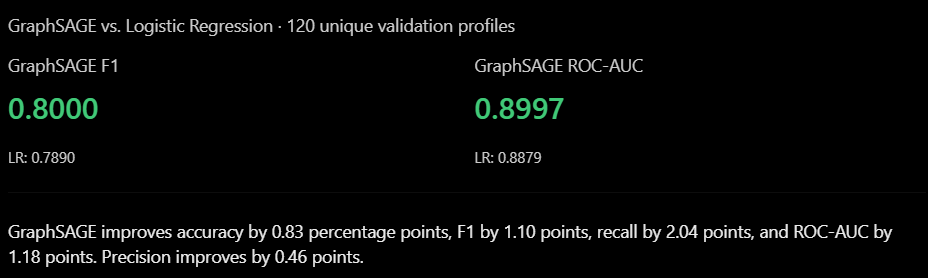

# **TEST EVALUATION**

In [75]:
variables_to_check = [
    "lr",
    "preprocessor",
    "model",
    "best_state",
    "edge_index",
    "edge_index_tv",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "train_idx",
    "val_idx",
    "test_idx",
    "X_tv",
    "y_tv",
    "data",
    "model_df",
    "profile_cols",
    "feature_cols",
    "graphsage_val_probs",
]

for name in variables_to_check:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: {type(obj).__name__}", end="")

        if hasattr(obj, "shape"):
            print(f", shape={obj.shape}")
        elif hasattr(obj, "edge_index") and obj.edge_index is not None:
            print(f", edge_index shape={tuple(obj.edge_index.shape)}")
        else:
            print()
    else:
        print(f"{name}: NOT FOUND")

lr: LogisticRegression
preprocessor: ColumnTransformer
model: GraphSAGE
best_state: OrderedDict
edge_index: Tensor, shape=torch.Size([2, 7620])
edge_index_tv: NOT FOUND
X_train: ndarray, shape=(814, 21)
X_val: ndarray, shape=(203, 21)
X_test: ndarray, shape=(263, 21)
y_train: ndarray, shape=(814,)
y_val: ndarray, shape=(203,)
y_test: ndarray, shape=(263,)
train_idx: ndarray, shape=(814,)
val_idx: ndarray, shape=(203,)
test_idx: ndarray, shape=(263,)
X_tv: ndarray, shape=(1017, 21)
y_tv: ndarray, shape=(1017,)
data: Data, edge_index shape=(2, 8137)
model_df: DataFrame, shape=(1280, 16)
profile_cols: list
feature_cols: list
graphsage_val_probs: ndarray, shape=(203,)


## **INSPECT THE GraphSAGE GRAPH**

In [76]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_tv:", X_tv.shape)

print("\nGraph data:")
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.edge_index.shape[1])

print("\nExisting edge_index:")
print("Shape:", tuple(edge_index.shape))

print("\nGraphSAGE model:")
print(model)

print("\nGraph data attributes:")
print(data)

# Check whether the stored best model state is available
print("\nBest state available:", best_state is not None)

# Confirm the expected train/validation/test row counts
print("\nSplit sizes:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Total:", len(train_idx) + len(val_idx) + len(test_idx))

X_train: (814, 21)
X_val: (203, 21)
X_test: (263, 21)
X_tv: (1017, 21)

Graph data:
Number of nodes: 1280
Number of edges: 8137

Existing edge_index:
Shape: (2, 7620)

GraphSAGE model:
GraphSAGE(
  (conv1): SAGEConv(21, 32, aggr=mean)
  (conv2): SAGEConv(32, 32, aggr=mean)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

Graph data attributes:
Data(x=[1280, 21], edge_index=[2, 8137], y=[1280])

Best state available: True

Split sizes:
Train: 814
Validation: 203
Test: 263
Total: 1280


# **EVALUATION OF THE GRAPH SAFELY**

In [77]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors

# The transformed matrices must already have been produced by a
# preprocessor fitted on training data only.
X_all = np.vstack([X_train, X_val, X_test]).astype(np.float32)

n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)
n_all = len(X_all)

assert n_all == 1280
assert n_train == 814
assert n_val == 203
assert n_test == 263

K = 5
device = torch.device("cpu")

# Find nearest neighbors among TRAINING nodes only.
# Fit the neighbor search on training nodes.
nn = NearestNeighbors(n_neighbors=min(K + 1, n_train), metric="cosine")
nn.fit(X_train)

# Training nodes: connect to their nearest training neighbors.
train_distances, train_neighbors = nn.kneighbors(X_train)

edges = set()

for i in range(n_train):
    for j in train_neighbors[i]:
        j = int(j)

        # Exclude self-loops at this stage.
        if i != j:
            edges.add((i, j))
            edges.add((j, i))

# Validation and test nodes connect only to training nodes.
# They cannot connect to each other.
for offset, X_split in [
    (n_train, X_val),
    (n_train + n_val, X_test)
]:
    _, neighbors = nn.kneighbors(X_split)

    for local_i, neighbor_list in enumerate(neighbors):
        node_i = offset + local_i

        for j in neighbor_list:
            j = int(j)
            edges.add((node_i, j))
            edges.add((j, node_i))

edge_index_final = torch.tensor(
    list(edges), dtype=torch.long
).t().contiguous()

print("All feature nodes:", X_all.shape)
print("Final edge index:", tuple(edge_index_final.shape))
print("Train nodes:", n_train)
print("Validation nodes:", n_val)
print("Test nodes:", n_test)

# Check that validation/test nodes connect only to training nodes.
src = edge_index_final[0].numpy()
dst = edge_index_final[1].numpy()

val_test_src = src[src >= n_train]
val_test_dst = dst[src >= n_train]

assert np.all(val_test_dst < n_train)

# No validation/test node should be the destination of an edge
# originating from another validation/test node.
assert np.all(dst[src >= n_train] < n_train)

print("Leakage checks passed: validation/test edges lead only to training nodes.")

All feature nodes: (1280, 21)
Final edge index: (2, 11182)
Train nodes: 814
Validation nodes: 203
Test nodes: 263
Leakage checks passed: validation/test edges lead only to training nodes.


# **TRAIN GraphSAGE WITH VALIDATION ONLY MODEL SELECTION**

In [82]:
import copy
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from sklearn.metrics import f1_score
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")

# Features ordered as train, validation, test
X_all = np.vstack([X_train, X_val, X_test]).astype(np.float32)

# Labels are stored for indexing, but test labels are NOT used
# for optimization or checkpoint selection.
y_all = np.concatenate([y_train, y_val, y_test])

X_tensor = torch.tensor(X_all, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y_all, dtype=torch.long, device=device)

train_mask = torch.zeros(len(X_all), dtype=torch.bool, device=device)
val_mask = torch.zeros(len(X_all), dtype=torch.bool, device=device)

train_mask[:n_train] = True
val_mask[n_train:n_train + n_val] = True

graph_data = Data(
    x=X_tensor,
    edge_index=edge_index_final.to(device),
    y=y_tensor
)

# Correct constructor: no num_classes argument
model = GraphSAGE(
    in_channels=X_train.shape[1],
    hidden_channels=32,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

best_val_f1 = -1.0
best_epoch = 0
best_state = None
patience = 30
epochs_without_improvement = 0
max_epochs = 300

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(graph_data.x, graph_data.edge_index)

    loss = F.cross_entropy(
        logits[train_mask],
        graph_data.y[train_mask]
    )

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(
            graph_data.x,
            graph_data.edge_index
        )
        val_probs = val_logits[val_mask].softmax(dim=1)[:, 1].cpu().numpy()
        val_preds = (val_probs >= 0.5).astype(int)

    val_f1 = f1_score(y_val, val_preds, zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        break

model.load_state_dict(best_state)

print("Training complete.")
print("Best epoch:", best_epoch)
print(f"Best validation F1: {best_val_f1:.4f}")
print("Epochs executed:", epoch)
print("Test metrics have NOT been calculated.")

Training complete.
Best epoch: 16
Best validation F1: 0.8000
Epochs executed: 46
Test metrics have NOT been calculated.


# **TEST EVALUATION**

In [83]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Restore the selected GraphSAGE checkpoint
model.load_state_dict(best_state)
model.eval()

# GraphSAGE probabilities for test nodes only
test_start = n_train + n_val
test_end = test_start + n_test

with torch.no_grad():
    logits = model(graph_data.x, graph_data.edge_index)
    test_probs_gnn = (
        logits[test_start:test_end]
        .softmax(dim=1)[:, 1]
        .cpu().numpy()
    )

# Logistic Regression probabilities
test_probs_lr = lr.predict_proba(X_test)[:, 1]

# Test labels are used ONLY now for final scoring
y_test_eval = np.asarray(y_test).astype(int)

def report_metrics(name, y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy:  {accuracy_score(y_true, preds):.4f}")
    print(f"Precision: {precision_score(y_true, preds, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, preds, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_true, preds, zero_division=0):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, probs):.4f}")
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(confusion_matrix(y_true, preds))
    return preds

lr_test_preds = report_metrics(
    "Logistic Regression — TEST",
    y_test_eval,
    test_probs_lr
)

gnn_test_preds = report_metrics(
    "GraphSAGE — TEST",
    y_test_eval,
    test_probs_gnn
)

# Build the test evaluation table
test_eval = model_df.iloc[test_idx].copy().reset_index(drop=True)
test_eval["actual"] = y_test_eval
test_eval["lr_probability"] = test_probs_lr
test_eval["lr_prediction"] = lr_test_preds
test_eval["graphsage_probability"] = test_probs_gnn
test_eval["graphsage_prediction"] = gnn_test_preds

# One representative row per unique clinical profile
unique_test = test_eval.drop_duplicates(
    subset=profile_cols,
    keep="first"
).copy()

print("\n" + "=" * 55)
print("UNIQUE-PROFILE TEST EVALUATION")
print("=" * 55)
print("Test rows:", len(test_eval))
print("Unique clinical profiles:", len(unique_test))

for model_name, prob_col, pred_col in [
    ("Logistic Regression", "lr_probability", "lr_prediction"),
    ("GraphSAGE", "graphsage_probability", "graphsage_prediction")
]:
    print(f"\n{model_name} — unique profiles")
    report_metrics(
        model_name,
        unique_test["actual"].to_numpy(),
        unique_test[prob_col].to_numpy()
    )


Logistic Regression — TEST
--------------------------
Accuracy:  0.8289
Precision: 0.7450
Recall:    0.9407
F1-score:  0.8315
ROC-AUC:   0.9224
Confusion matrix [[TN, FP], [FN, TP]]:
[[107  38]
 [  7 111]]

GraphSAGE — TEST
----------------
Accuracy:  0.8669
Precision: 0.7902
Recall:    0.9576
F1-score:  0.8659
ROC-AUC:   0.9238
Confusion matrix [[TN, FP], [FN, TP]]:
[[115  30]
 [  5 113]]

UNIQUE-PROFILE TEST EVALUATION
Test rows: 263
Unique clinical profiles: 149

Logistic Regression — unique profiles

Logistic Regression
-------------------
Accuracy:  0.8054
Precision: 0.7222
Recall:    0.9420
F1-score:  0.8176
ROC-AUC:   0.9045
Confusion matrix [[TN, FP], [FN, TP]]:
[[55 25]
 [ 4 65]]

GraphSAGE — unique profiles

GraphSAGE
---------
Accuracy:  0.8322
Precision: 0.7500
Recall:    0.9565
F1-score:  0.8408
ROC-AUC:   0.9069
Confusion matrix [[TN, FP], [FN, TP]]:
[[58 22]
 [ 3 66]]


# **COMPARISON WRT LOGISTIC REGRESSION**

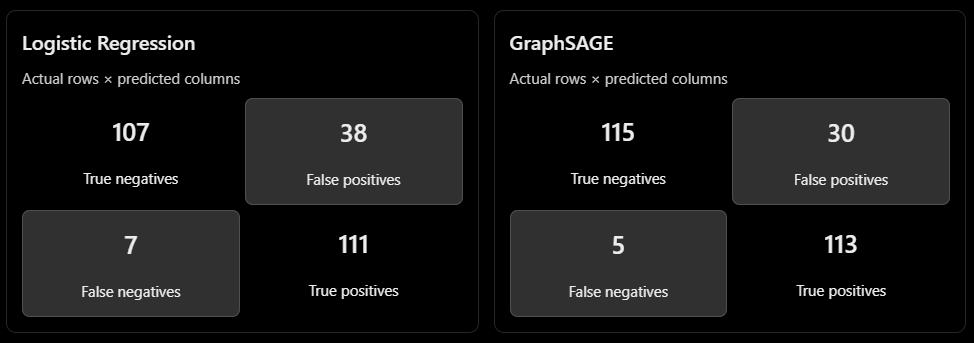

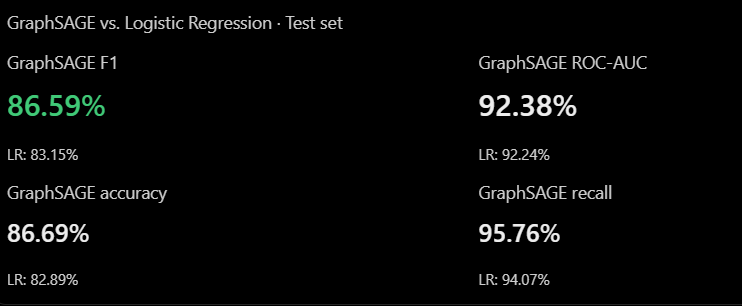

# **VERIFY THE GRAPH AND SPLIT SIZE**

In [84]:
print("Feature matrix:", X_all.shape)
print("Graph edge index:", edge_index_final.shape)

print("\nSplit sizes:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nGraph nodes:", graph_data.num_nodes)
print("Graph edges:", graph_data.num_edges)

assert len(train_idx) + len(val_idx) + len(test_idx) == len(X_all)
assert graph_data.num_nodes == len(X_all)
assert edge_index_final.shape[0] == 2

print("\nBasic checks passed.")

Feature matrix: (1280, 21)
Graph edge index: torch.Size([2, 11182])

Split sizes:
Train: 814
Validation: 203
Test: 263

Graph nodes: 1280
Graph edges: 11182

Basic checks passed.


# **CHECK FOR INVALID EDGES AND SELF-LOOPS**

In [85]:
print("Feature matrix:", X_all.shape)
print("Graph edge index:", edge_index_final.shape)

print("\nSplit sizes:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nGraph nodes:", graph_data.num_nodes)
print("Graph edges:", graph_data.num_edges)

assert len(train_idx) + len(val_idx) + len(test_idx) == len(X_all)
assert graph_data.num_nodes == len(X_all)
assert edge_index_final.shape[0] == 2

print("\nBasic checks passed.")

Feature matrix: (1280, 21)
Graph edge index: torch.Size([2, 11182])

Split sizes:
Train: 814
Validation: 203
Test: 263

Graph nodes: 1280
Graph edges: 11182

Basic checks passed.


# **CHECK WHICH SPLITS ARE VALID**

In [86]:
# Step 3: Audit cross-split edges

n_train = len(train_idx)
n_val = len(val_idx)
n_test = len(test_idx)

# The graph node ordering should be:
# [training nodes, validation nodes, test nodes]

train_nodes = set(range(0, n_train))
val_nodes = set(range(n_train, n_train + n_val))
test_nodes = set(range(n_train + n_val, n_train + n_val + n_test))

src = edge_index_final[0].cpu().numpy()
dst = edge_index_final[1].cpu().numpy()

def count_edges_between(source_nodes, destination_nodes):
    return sum(
        (int(u) in source_nodes and int(v) in destination_nodes)
        for u, v in zip(src, dst)
    )

print("Train -> Train:",
      count_edges_between(train_nodes, train_nodes))
print("Train -> Validation:",
      count_edges_between(train_nodes, val_nodes))
print("Validation -> Validation:",
      count_edges_between(val_nodes, val_nodes))
print("Train -> Test:",
      count_edges_between(train_nodes, test_nodes))
print("Validation -> Test:",
      count_edges_between(val_nodes, test_nodes))
print("Test -> Test:",
      count_edges_between(test_nodes, test_nodes))

Train -> Train: 5590
Train -> Validation: 1218
Validation -> Validation: 0
Train -> Test: 1578
Validation -> Test: 0
Test -> Test: 0


# **VERIFY THE GRAPH DOESN'T CONTAIN DUPLICATES**

In [87]:
# Step 4: Check duplicate edges

edge_pairs = list(zip(
    edge_index_final[0].cpu().tolist(),
    edge_index_final[1].cpu().tolist()
))

unique_edges = set(edge_pairs)

print("Total directed edges:", len(edge_pairs))
print("Unique directed edges:", len(unique_edges))
print("Duplicate directed edges:", len(edge_pairs) - len(unique_edges))

Total directed edges: 11182
Unique directed edges: 11182
Duplicate directed edges: 0


# **VERIFICATION TEST**

In [88]:
n_train = len(train_idx)
n_val = len(val_idx)
n_test = len(test_idx)

expected_train_mask = torch.zeros(
    graph_data.num_nodes, dtype=torch.bool
)
expected_train_mask[:n_train] = True

expected_val_mask = torch.zeros(
    graph_data.num_nodes, dtype=torch.bool
)
expected_val_mask[n_train:n_train + n_val] = True

expected_test_mask = torch.zeros(
    graph_data.num_nodes, dtype=torch.bool
)
expected_test_mask[n_train + n_val:] = True

print("Training mask correct:",
      torch.equal(graph_data.train_mask.cpu(), expected_train_mask)
      if hasattr(graph_data, "train_mask") else
      "No train_mask stored in graph_data")

print("Validation mask correct:",
      torch.equal(graph_data.val_mask.cpu(), expected_val_mask)
      if hasattr(graph_data, "val_mask") else
      "No val_mask stored in graph_data")

print("Test mask correct:",
      torch.equal(graph_data.test_mask.cpu(), expected_test_mask)
      if hasattr(graph_data, "test_mask") else
      "No test_mask stored in graph_data")

print("\nCheck the training loop:")
print("Training loss must use only training-node labels.")
print("Validation labels may be used for early stopping.")
print("Test labels must not influence training or model selection.")

Training mask correct: No train_mask stored in graph_data
Validation mask correct: No val_mask stored in graph_data
Test mask correct: No test_mask stored in graph_data

Check the training loop:
Training loss must use only training-node labels.
Validation labels may be used for early stopping.
Test labels must not influence training or model selection.


# **INSPECT TRAINING SETUP**

In [89]:
print("Graph data attributes:")
print(graph_data)

print("\nAvailable variables related to training:")
for name in [
    "train_mask", "val_mask", "test_mask",
    "train_idx", "val_idx", "test_idx",
    "best_state", "best_epoch",
    "graph_data", "model"
]:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: type={type(obj).__name__}")
    else:
        print(f"{name}: not found")

Graph data attributes:
Data(x=[1280, 21], edge_index=[2, 11182], y=[1280])

Available variables related to training:
train_mask: type=Tensor
val_mask: type=Tensor
test_mask: not found
train_idx: type=ndarray
val_idx: type=ndarray
test_idx: type=ndarray
best_state: type=OrderedDict
best_epoch: type=int
graph_data: type=Data
model: type=GraphSAGE


# **VERIFY TRAIN, TEST AND VAL**

In [90]:
import numpy as np
import torch

n_train = len(train_idx)
n_val = len(val_idx)
n_test = len(test_idx)
n_total = graph_data.num_nodes

expected_train = torch.zeros(n_total, dtype=torch.bool)
expected_train[:n_train] = True

expected_val = torch.zeros(n_total, dtype=torch.bool)
expected_val[n_train:n_train + n_val] = True

expected_test = torch.zeros(n_total, dtype=torch.bool)
expected_test[n_train + n_val:] = True

# Compare masks, accounting for their device
print("Train mask matches split:",
      torch.equal(train_mask.cpu(), expected_train))

print("Validation mask matches split:",
      torch.equal(val_mask.cpu(), expected_val))

print("Train/validation masks overlap:",
      bool((train_mask.cpu() & val_mask.cpu()).any()))

print("Training nodes:", int(train_mask.sum().item()))
print("Validation nodes:", int(val_mask.sum().item()))
print("Expected test nodes:", n_test)

print("All nodes accounted for:",
      n_train + n_val + n_test == n_total)

Train mask matches split: True
Validation mask matches split: True
Train/validation masks overlap: False
Training nodes: 814
Validation nodes: 203
Expected test nodes: 263
All nodes accounted for: True


# **VERIFICATION**

In [91]:
print("Best epoch:", best_epoch)
print("Best validation F1:", round(best_val_f1, 4))
print("Checkpoint available:", best_state is not None)

assert best_state is not None
assert best_epoch > 0
assert len(train_mask) == graph_data.num_nodes
assert len(val_mask) == graph_data.num_nodes

print("\nCheckpoint and mask checks passed.")
print("No retraining performed.")

Best epoch: 16
Best validation F1: 0.8
Checkpoint available: True

Checkpoint and mask checks passed.
No retraining performed.


# **UNDERSTANDING FEATURES USED BY LOGISTIC REGRESSION**

In [92]:
import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Extract model coefficients
coefficients = lr.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_importance": np.abs(coefficients)
})

# Sort by absolute coefficient magnitude
importance_df = importance_df.sort_values(
    "absolute_importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 features by absolute coefficient:")
display(importance_df.head(15))

Top 15 features by absolute coefficient:


,feature,coefficient,absolute_importance
0,cat__cp_4.0,1.153169,1.153169
1,cat__slope_2.0,1.077932,1.077932
2,cat__slope_1.0,-0.811353,0.811353
3,cat__sex_0.0,-0.775003,0.775003
4,cat__sex_1.0,0.772341,0.772341
5,cat__cp_2.0,-0.720838,0.720838
6,num__oldpeak,0.474781,0.474781
7,num__age,0.405538,0.405538
8,cat__exang_0.0,-0.394546,0.394546
9,cat__exang_1.0,0.391884,0.391884


# **VISUALIZE FEATURE IMPORTANCE**

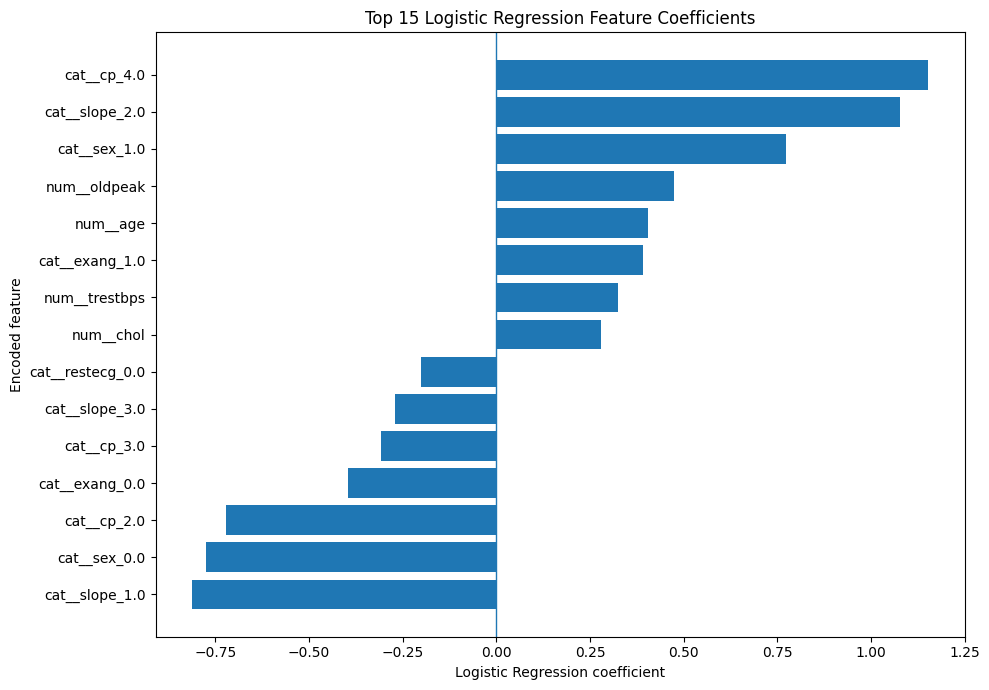

In [93]:
import matplotlib.pyplot as plt

# Select the 15 most influential encoded features
plot_df = importance_df.head(15).copy()

# Sort for a horizontal bar chart
plot_df = plot_df.sort_values("coefficient")

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Encoded feature")
plt.title("Top 15 Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

# **TARGET MAPPING CONFIRMATION**

In [94]:
print("Target mapping:")
print(df_clean["target"].value_counts(dropna=False).sort_index())

print("\nTarget data type:")
print(df_clean["target"].dtype)

print("\nSource target conventions:")
print(df_clean.groupby("source")["target"].agg(
    ["count", "min", "max", "mean"]
))

Target mapping:
target
0    785
1    893
Name: count, dtype: int64

Target data type:
int64

Source target conventions:
                         count  min  max      mean
source                                            
fedesoriano_heart          760    0    1  0.506579
uci_multi_cleveland        304    0    1  0.457237
uci_multi_hungary          292    0    1  0.363014
uci_multi_switzerland      123    0    1  0.934959
uci_multi_va long beach    199    0    1  0.743719


# **CHECK PERFORMANCE BY SCORE**

In [95]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Original rows corresponding to the grouped evaluation
test_df = model_df.iloc[test_idx].copy()

# Existing LR model and already-transformed test features
test_probs = lr.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_df["y_true"] = y_test
test_df["y_pred"] = test_preds
test_df["y_prob"] = test_probs

results = []

for source, group in test_df.groupby("source"):
    y_true = group["y_true"]
    y_pred = group["y_pred"]
    y_prob = group["y_prob"]

    results.append({
        "source": source,
        "n": len(group),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "roc_auc": (
            roc_auc_score(y_true, y_prob)
            if y_true.nunique() == 2 else np.nan
        )
    })

source_results = pd.DataFrame(results)
display(source_results.round(3))

,source,n,positive_rate,accuracy,precision,recall,f1,roc_auc
0,fedesoriano_heart,129,0.426,0.876,0.800,0.945,0.867,0.957
1,uci_multi_cleveland,61,0.541,0.770,0.732,0.909,0.811,0.893
2,uci_multi_hungary,55,0.309,0.800,0.615,0.941,0.744,0.890
3,uci_multi_va long beach,18,0.722,0.778,0.765,1.000,0.867,0.785


# **INSPECT CATEGORICAL VALUES**

In [96]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg", "exang", "slope"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(
        df_clean.groupby("source")[col]
        .agg(lambda s: sorted(s.dropna().unique().tolist()))
        .to_frame("observed_values")
    )


--- sex ---


,observed_values
source,
fedesoriano_heart,"[0, 1]"
uci_multi_cleveland,"[0, 1]"
uci_multi_hungary,"[0, 1]"
uci_multi_switzerland,"[0, 1]"
uci_multi_va long beach,"[0, 1]"



--- cp ---


,observed_values
source,
fedesoriano_heart,"[1, 2, 3, 4]"
uci_multi_cleveland,"[1, 2, 3, 4]"
uci_multi_hungary,"[1, 2, 3, 4]"
uci_multi_switzerland,"[1, 2, 3, 4]"
uci_multi_va long beach,"[1, 2, 3, 4]"



--- fbs ---


...

,observed_values
source,
fedesoriano_heart,"[0.0, 1.0, 2.0]"
uci_multi_cleveland,"[0.0, 1.0, 2.0]"
uci_multi_hungary,"[0.0, 1.0, 2.0]"
uci_multi_switzerland,"[0.0, 1.0, 2.0]"
uci_multi_va long beach,"[0.0, 1.0, 2.0]"



--- exang ---


,observed_values
source,
fedesoriano_heart,"[0.0, 1.0]"
uci_multi_cleveland,"[0.0, 1.0]"
uci_multi_hungary,"[0.0, 1.0]"
uci_multi_switzerland,"[0.0, 1.0]"
uci_multi_va long beach,"[0.0, 1.0]"



--- slope ---


,observed_values
source,
fedesoriano_heart,"[1.0, 2.0, 3.0]"
uci_multi_cleveland,"[1.0, 2.0, 3.0]"
uci_multi_hungary,"[1.0, 2.0, 3.0]"
uci_multi_switzerland,"[1.0, 2.0, 3.0]"
uci_multi_va long beach,"[1.0, 2.0, 3.0]"


# **CATEGORICAL AND MISSING DATA AUDIT**

In [97]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg", "exang", "slope"
]

print("Missing categorical values by source:")
display(
    df_clean.groupby("source")[categorical_cols]
    .agg(lambda s: s.isna().sum())
)

print("\nUnique category counts:")
display(
    df_clean.groupby("source")[categorical_cols]
    .nunique()
)

Missing categorical values by source:


,sex,cp,fbs,restecg,exang,slope
source,,,,,,
fedesoriano_heart,0,0,0,0,0,0
uci_multi_cleveland,0,0,0,0,0,1
uci_multi_hungary,0,0,8,1,1,188
uci_multi_switzerland,0,0,75,1,1,17
uci_multi_va long beach,0,0,7,0,53,101



Unique category counts:


,sex,cp,fbs,restecg,exang,slope
source,,,,,,
fedesoriano_heart,2,4,2,3,2,3
uci_multi_cleveland,2,4,2,3,2,3
uci_multi_hungary,2,4,2,3,2,3
uci_multi_switzerland,2,4,2,3,2,3
uci_multi_va long beach,2,4,2,3,2,3


# **SAVE MODELS AND PREPROCESSING ATRIFACTS**

In [98]:
import os
import json
import joblib
import torch

ARTIFACT_DIR = "/content/heart_disease_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save the fitted sklearn preprocessing pipeline and baseline model
joblib.dump(
    preprocessor,
    f"{ARTIFACT_DIR}/preprocessor.joblib"
)

joblib.dump(
    lr,
    f"{ARTIFACT_DIR}/logistic_regression.joblib"
)

# Save GraphSAGE checkpoint and architecture configuration
torch.save(
    {
        "model_state_dict": best_state,
        "in_channels": int(X_train.shape[1]),
        "hidden_channels": 32,
        "dropout": 0.2,
        "best_epoch": int(best_epoch),
        "best_validation_f1": float(best_val_f1),
    },
    f"{ARTIFACT_DIR}/graphsage_checkpoint.pt"
)

# Save feature configuration
config = {
    "feature_cols": list(feature_cols),
    "continuous_cols": list(continuous_cols),
    "categorical_cols": list(categorical_cols),
    "target_col": "target",
    "positive_class": 1,
    "graph_nodes": int(graph_data.num_nodes),
    "graph_edges": int(graph_data.num_edges),
}

with open(f"{ARTIFACT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
for filename in sorted(os.listdir(ARTIFACT_DIR)):
    print(filename)

Saved artifacts:
config.json
graphsage_checkpoint.pt
logistic_regression.joblib
preprocessor.joblib


# **DOWNLOAD ARTIFACT ZIP**

In [99]:
import shutil

zip_path = shutil.make_archive(
    "/content/heart_disease_artifacts",
    "zip",
    ARTIFACT_DIR
)

print("Archive created:", zip_path)

Archive created: /content/heart_disease_artifacts.zip
